# FRB Constraints on cosmological parameters and cosmic baryons

**Import packages**

In [1]:
import sys
sys.path.append('../../Python_scripts')

from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *
from create_mock_frb import create_mock_frb_data

from scipy.stats import chi2
from scipy.stats import gaussian_kde

## Reading FRB data

[x] Are there duplicates? Which are these?

- ${\rm DM}$ is the total observed dispersion measure
- ${\rm DM}_{\rm ext}$ is the extragalactic dispersion measure (correcting for MW)

In [2]:
frb_data=pd.read_csv('../../Data/FRB.csv')
frb_data

,FRB,z,DM,DM_ext,From
0,FRB 20180814A,0.06800,190.900,73.30,Fan
1,FRB 20181030A,0.00385,103.396,32.30,Fan
2,FRB 20220529A,0.18390,246.000,176.00,Fan
3,FRB 20220610A,1.01600,1458.150,1397.15,Fan
4,FRB 20220717A,0.36295,637.340,489.04,Fan
...,...,...,...,...,...
112,FRB 20231204A,0.06440,221.000,159.94,CHIME2025
113,FRB 20231206A,0.06590,457.700,370.12,CHIME2025
114,FRB 20231223C,0.10590,165.800,87.07,CHIME2025
115,FRB 20231229A,0.01900,198.500,110.98,CHIME2025


In [3]:
(frb_data['z'].values).size, np.unique(frb_data['z'].values).size, np.unique(frb_data['DM_ext'].values).size

(117, 114, 117)

In [4]:
duplicates = []

for idx_1, frb_1 in enumerate(frb_data['FRB']):
    for idx_2, frb_2 in enumerate(frb_data['FRB']):
        if ((frb_data['z'][idx_1] == frb_data['z'][idx_2]) or (frb_data['DM_ext'][idx_1] == frb_data['DM_ext'][idx_2])) and (idx_1 != idx_2):
            duplicates.append(idx_1)

In [5]:
duplicates

[7, 23, 33, 39, 91, 96]

In [6]:
for idx in duplicates:
    print(f"FRB name: {frb_data['FRB'][idx]} has z={frb_data['z'][idx]} and DM_ext={frb_data['DM_ext'][idx]}, and DM_obs={frb_data['DM'][idx]}.")

FRB name: FRB 20230814A has z=0.553 and DM_ext=561.6, and DM_obs=696.4.
FRB name: FRB 20220726A has z=0.3619 and DM_ext=571.37, and DM_obs=686.55.
FRB name: FRB 20221219A has z=0.553 and DM_ext=632.3, and DM_obs=706.708.
FRB name: FRB 20230628A has z=0.127 and DM_ext=276.35, and DM_obs=344.952.
FRB name: FRB 20230902A has z=0.3619 and DM_ext=376.1, and DM_obs=440.1.
FRB name: FRB 20240310A has z=0.127 and DM_ext=535.8, and DM_obs=601.8.


**Note**: All FRBs are different, but some of them share the same redshift

**FRB cuts**

We perform two cuts in the FRBs analysis:

- Remove two FRBs that have very large DMs for their redshift
- We perform a redshift cut (for small redshifts), since these are creating an issue with the variance calculation

In [8]:
z_cut=0.2

## Cutting the data
frb_data_cut = frb_data[frb_data['FRB'] != 'FRB 20190520B']
frb_data_cut = frb_data[frb_data['FRB'] != 'FRB 20220831A']
frb_data_cut = frb_data[frb_data['z'] >= z_cut]

print(f"Original data had {len(frb_data)}, while the cut data have {len(frb_data_cut)} FRBs.")

Original data had 117, while the cut data have 58 FRBs.


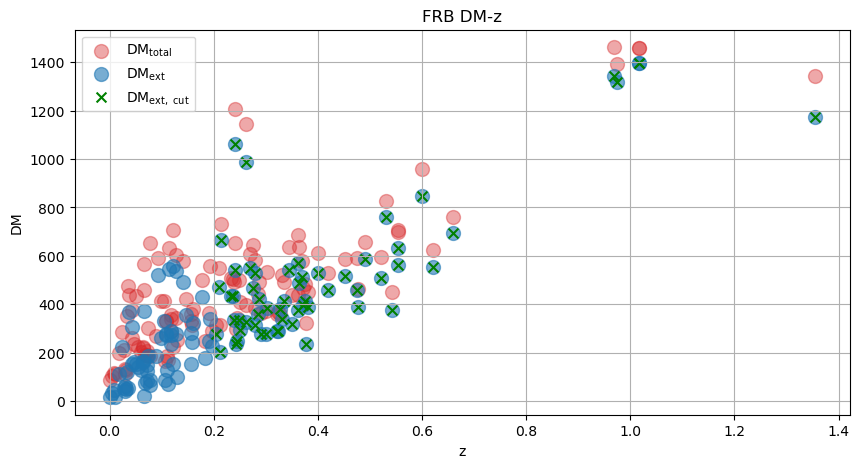

In [14]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)

ax1.scatter(frb_data['z'], frb_data['DM'], s=100, marker='o', label=r'DM$_{\rm total}$', alpha=0.4, c='tab:red')
ax1.scatter(frb_data['z'], frb_data['DM_ext'], s=100, marker='o', label=r'DM$_{\rm ext}$', alpha=0.6)
ax1.scatter(frb_data_cut['z'], frb_data_cut['DM_ext'], s=50, marker='x', label=r'DM$_{\rm ext,\ cut}$', c='green')

ax1.set_xlabel(r'z')
ax1.set_ylabel(r'DM')
ax1.set_title('FRB DM-z')
ax1.grid(True)
ax1.legend(loc='upper left')

plt.show()

**Fitting some lines in the FRB data**

We investigate 3 cases, where in all we fit a least-squares linear relation ($y = a+b x$):

- Fit all FRBs
- Fit FRBs at lower redshifts (z<0.8)
- Fit FRBs after the cut
- Fit FRBs after the cut (at lower redshifts)

Finally, we plot the theoretical ${\rm DM}_{\rm IGM}$ for the relevant redshifts. Note that the theoretical IGM contribution relation, is **not** including any host effects, that's why it is smaller than most DM values.

In [20]:
slope_all, intercept_all = np.polyfit(frb_data['z'], frb_data['DM_ext'], 1)
slope_cut, intercept_cut = np.polyfit(frb_data_cut['z'], frb_data_cut['DM_ext'], 1)

bool_z = frb_data['z']<0.8
slope_lowz, intercept_lowz = np.polyfit(frb_data['z'][bool_z], frb_data['DM_ext'][bool_z], 1)

bool_z_cut = frb_data_cut['z']<0.8
slope_lowz_cut, intercept_lowz_cut = np.polyfit(frb_data_cut['z'][bool_z_cut], frb_data_cut['DM_ext'][bool_z_cut], 1)

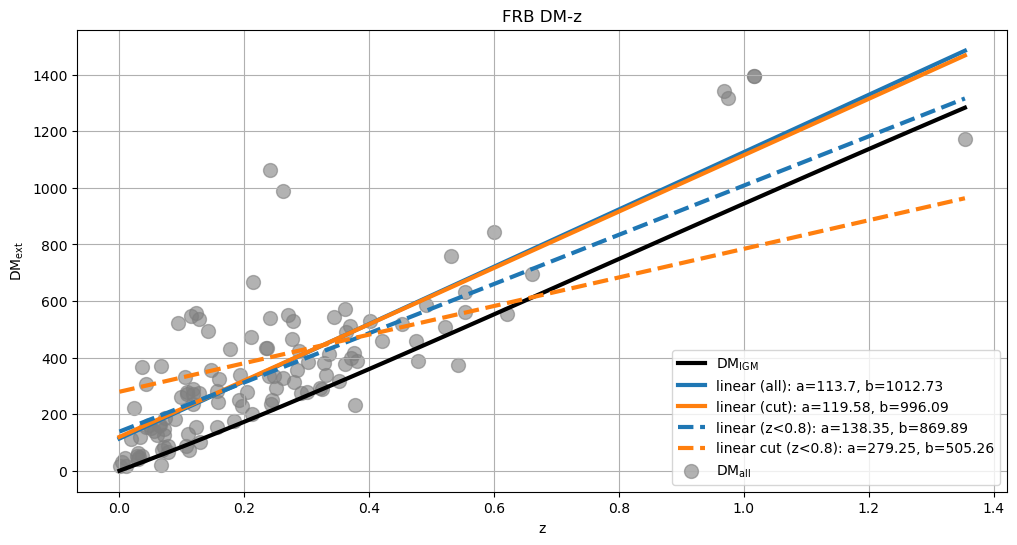

In [24]:
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(frb_data['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, DM_theory, lw=3, c='black', label=r'DM$_{\rm IGM}$')

ax1.plot(z_range, intercept_all+slope_all*z_range, lw=3, c='tab:blue', ls='-',\
         label=f'linear (all): a={round(intercept_all,2)}, b={round(slope_all,2)}')

ax1.plot(z_range, intercept_cut+slope_cut*z_range, lw=3, c='tab:orange', ls='-',\
         label=f'linear (cut): a={round(intercept_cut,2)}, b={round(slope_cut,2)}')

ax1.plot(z_range, intercept_lowz+slope_lowz*z_range, lw=3, c='tab:blue', ls='--',\
         label=f'linear (z<0.8): a={round(intercept_lowz,2)}, b={round(slope_lowz,2)}')

ax1.plot(z_range, intercept_lowz_cut+slope_lowz_cut*z_range, lw=3, c='tab:orange', ls='--',\
         label=f'linear cut (z<0.8): a={round(intercept_lowz_cut,2)}, b={round(slope_lowz_cut,2)}')


ax1.scatter(frb_data['z'], frb_data['DM_ext'], s=100, marker='o', label=r'DM$_{\rm all}$', alpha=0.6, c='tab:grey')

ax1.set_xlabel('z')
ax1.set_ylabel(r'DM$_{\rm ext}$')
ax1.set_title('FRB DM-z')
ax1.grid(True)
ax1.legend()


plt.show()

**Note 1**: The FRB cut (z<0.8) is reducing the slope of the linear fit (especially in the cut case).

**Note 2**: The theoretical ${\rm DM}_{\rm IGM}$ scaling, is very similar to the linear fit, when all $z$ FRBs are considered.

------------------------------------------------------

## Preparation

search F range 

In [11]:
F_array=np.linspace(1.0, 18.0, 5)
sigma_host_array=np.linspace(0.2,1.4,10)
e_mu_array=np.linspace(50, 250, 10)

sigma variance relation

In [12]:
z_min=np.min(frb_data_cut['z'])
z_max=np.max(frb_data_cut['z'])
F_min=np.min(F_array)
F_max=np.max(F_array)
vars=[f_variance_delta(F_min,z_min),f_variance_delta(F_max,z_min),f_variance_delta(F_max,z_max),f_variance_delta(F_min,z_max)]
var_min=np.min(vars)
var_max=np.max(vars)
print([var_min,var_max])

[0.41855386865432265, 76.46371879346626]


In [13]:
s=2.554
C0=C0_sigma(s)
A=find_A_sigma(C_0=C0,sigma=s)
Af=find_A_sigma_fast(C_0=C0,sigma=s)

print([C0, A, Af])

[-2.0144531945899793, 0.5481994070884026, 0.5481992326782293]


../../Python_scripts\cosmo_support.py:677: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  second_moment, _ = quad(second_moment_integrand, x_min, x_max,limit=limit)


80.54014114295425
0.00010023109830714638


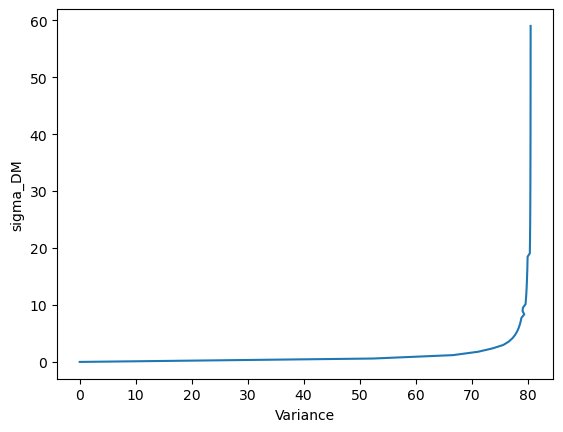

In [14]:
Sigmas=np.linspace(0.01, 59, 100)
Vars=np.zeros_like(Sigmas)

for i, sigma in enumerate(Sigmas):
    C0=C0_sigma(sigma)
    A = find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3)
    Vars[i]=calculate_var(C0=C0, A=A, sigma_DM=sigma)
    
plt.plot(Vars, Sigmas)
plt.ylabel('sigma_DM')
plt.xlabel('Variance')

print(np.max(Vars))
print(np.min(Vars))

In [23]:
sigma_var = interpolate.interp1d(np.sqrt(Vars), Sigmas, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [16]:
var=4
# 4.185538686543227
print(sigma_var(np.sqrt(var)))

0.17403681853078237


In [17]:
sigmas=[sigma_var(np.sqrt(var_min)),sigma_var(np.sqrt(var_max))]
sigma_min=np.min(sigmas)
sigma_max=np.max(sigmas)
print([sigma_min,sigma_max])

[0.06250410870237134, 3.4775131881213084]


In [18]:
sigma_rsl=200
# sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
sigmas=np.linspace(0.1, 59.0, sigma_rsl)
print([np.min(sigmas),np.max(sigmas)])
C0s=np.zeros_like(sigmas)
As=np.zeros_like(sigmas)
for i, sigma in enumerate(sigmas):
    C0=C0_sigma(sigma)
    C0s[i]=C0
    As[i]=find_A_sigma(C_0=C0, sigma=sigma)

[0.1, 59.0]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


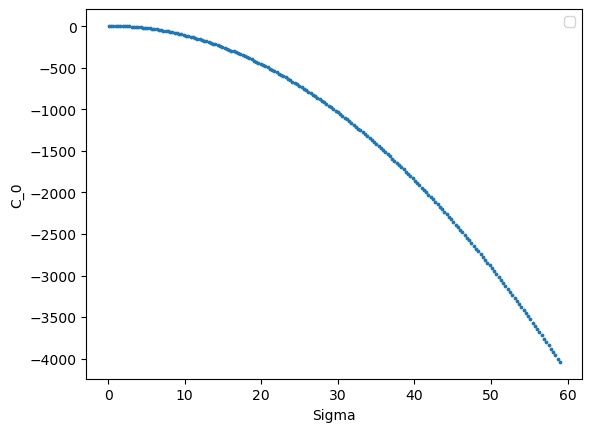

In [19]:
plt.scatter(sigmas, C0s,  s=3)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


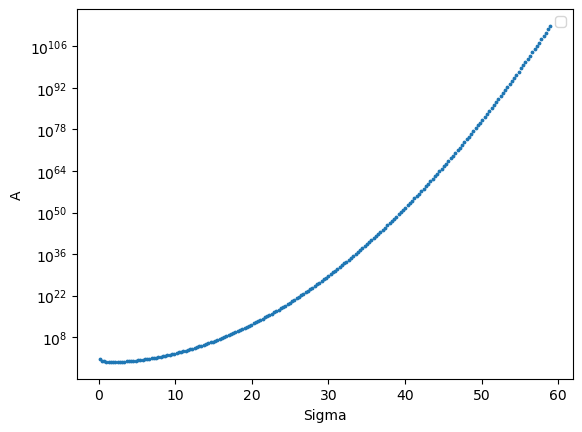

In [20]:
plt.scatter(sigmas, As,  s=3)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
plt.legend()

plt.show()

-------------------------------------------------------------

NameError: name 'data' is not defined

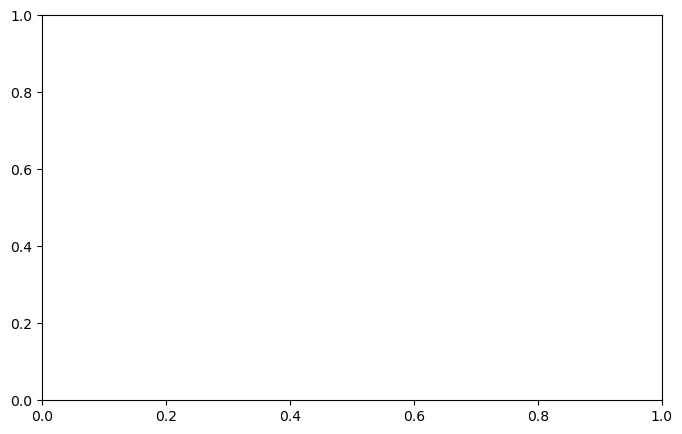

In [21]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0.1, np.max(data['z']), 100)
y_high = np.zeros_like(z_range)
y_low = np.zeros_like(z_range)

a = 1012.73
b = 113.70
DM_linear = a*z_range+b

DM_theory = np.zeros_like(z_range)

## The range of DM_cosmic (the y-axis)
DM_cosmic_range = np.linspace(0.01, 2000, 2000)
    

for idx, z in enumerate(z_range):
    sigma=sigma_var(np.sqrt(f_variance_delta(F=5.5, z=z)))
    C0 = find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3)
    DM_theory[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)
    
    ## The range of DM_cosmic (the y-axis)
    # DM_cosmic_range = np.linspace(0.01, np.max(data['DM_ext'])/(DM_theory[idx]), 1000)
    p=pdf_DM_cosmo(DM_cosmic_range/(100+DM_theory[idx]), C_0=C0, A=A, sigma=sigma)
    
    ## Calculating the 5% and 95% limits, to plot the shaded area
    cdf = np.cumsum(normalise(p))
    y_high[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.95))]
    y_low[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.05))]
    

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label=r'DM$_{\rm IGM}$ theory')
ax1.plot(z_range, DM_linear, lw=2, ls='--', c='tab:red', label=r'DM$_{\rm IGM}$ linear')
ax1.fill_between(z_range, y_low, y_high, alpha=0.2, color='grey', label=r'$90\%$')


ax1.scatter(data['z'], data['DM_ext'], s=50, marker='+', label=r'DM$_{\rm corr}$')  

ax1.set_xlabel('z')
ax1.set_ylabel(r'DM$_{\rm IGM}$')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

Constrain $H_0 \Omega_0 f_{IGM}=const $

In [17]:
def DM_IGM_H0_O_b_f_IGM(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, Om, w):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    integral, _ = quad(integrand, 0, z, args=(Om, w))
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [3]:
def DM_IGM_H0_O_b_f_IGM_fast(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=W_LAMBDA):
    
    def integrand(z, Om, w):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    z_array = np.linspace(0, z, 1000)
    integral = np.trapz(integrand(z_array, Om, w), x=z_array)
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [19]:
z=1.00
print(DM_IGM_O_bh_70(z=z, O_bh_70=OMEGA_BARYONS*HUBBLE/70.0))
print(DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HUBBLE*OMEGA_BARYONS*f_IGM))

944.0949564541271
912.8582288974072


In [20]:
print(DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HUBBLE*OMEGA_BARYONS*f_IGM))

912.8581855784383


In [21]:
def calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    # print([f_variance_delta(F,z),sigma,C_0, A])
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

**MK**: Need to cross-check this

In [97]:
def calculate_dm_probability_gauss(DM_frb_max, z, HOf, A_diff, DM_mu_host, A_host,\
                                   Om=OMEGA_MATTER, w=W_LAMBDA):
    
    DM_array = np.linspace(0.001, DM_frb_max*(1+z), 5000)    
    # DM_array = np.linspace(0.001, DM_frb_max, 5000)    
    
    ## Cosmic calculation    
    DM_IGM = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=Om, w=w)
    pdf_cosmic = Gaussian(DM_frb_max-DM_array/(1+z), DM_IGM, A_diff*DM_IGM)
    
    
    ## Host calculation
    pdf_host = Gaussian(DM_array, DM_mu_host, A_host*DM_mu_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=DM_array)
        
    return prob

In [25]:
def calculate_dm_probability_gauss_convo(DM_frb_max, z, HOf, A_diff, DM_mu_host, A_host,\
                                   Om=OMEGA_MATTER, w=W_LAMBDA):
        
    ## Cosmic calculation    
    DM_IGM = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=Om, w=w)
    
    ## Error calculation
    sigma = np.sqrt((A_diff*DM_IGM)**2+(A_host*DM_mu_host/(1+z))**2)
    
    ## Combine together
    prob = Gaussian(DM_frb_max, DM_IGM+DM_mu_host/(1+z), sigma)
        
    return prob

In [ ]:
def calculate_3D_dm_probability_gauss_convo(DM_frb_max, z, HOf, DM_mu_host, A_sigma,\
                                   Om=OMEGA_MATTER, w=W_LAMBDA):
        
    ## Cosmic calculation    
    DM_IGM = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=Om, w=w)
    DM_tot = DM_IGM+DM_mu_host/(1+z)
    
    ## Error calculation
    sigma = A_sigma*DM_tot
    
    ## Combine together
    prob = Gaussian(DM_frb_max, DM_tot, sigma)
        
    return prob

In [23]:
def calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta_fast(F,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma_fast(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    # print([f_variance_delta(F,z),sigma,C_0, A])
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [100]:
DM_frb_max=1174.1
z=1.354
F=10.0
HOf=3.0
e_mu=200
sigma_host=0.6

# print(calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host))
# print(calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host))
# print(calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host))
print(calculate_dm_probability_gauss(DM_frb_max, z, HOf, 0.1, 50, 0.1))
print(calculate_dm_probability_gauss_convo(DM_frb_max, z, HOf, 0.1, 50, 0.1))

0.0012432063661986955
0.0012432063661986952


In [25]:
import timeit

def timer_calculate_dm_probability():
    return calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host)

def timer_calculate_dm_prob():
    return calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host)

# time 
execution_time = timeit.timeit(timer_calculate_dm_probability, number=10)
print(f"calculate_dm_probability_mac time: {execution_time:.6f} seconds")
execution_time = timeit.timeit(timer_calculate_dm_prob, number=10)
print(f"calculate_dm_probability time: {execution_time:.6f} seconds")

NameError: name 'sigma_var' is not defined

**NEED to fix some quads in the `cosmo_support`**

In [28]:
HOf_fiducial=70*OMEGA_BARYONS*0.9
print(HOf_fiducial)

3.0851100000000002


In [63]:
# F defined before
HOf_array=np.linspace(1.0, 5.0, 10)

F_4D, HOf_array_4D, sigma_host_4D, e_mu_4D = np.meshgrid(
    F_array, HOf_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

F_h, h_F = np.meshgrid(F_array, HOf_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, HOf_array_4D: {HOf_array_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (5, 10, 10, 10), HOf_array_4D: (5, 10, 10, 10), sigma_host_4D: (5, 10, 10, 10), e_mu_4D: (5, 10, 10, 10)
Shape of F_h: (10, 5), h_F: (10, 5), F_sigma: (10, 5), sigma_F: (10, 5), F_e_mu: (10, 5), e_mu_F: (10, 5)


In [24]:
# posterior_4D = 1.0 + np.zeros_like(F_4D, dtype= np.float128)
log_posterior_4D = np.zeros_like(F_4D, dtype= np.float64)
# Calculate total iterations for progress bar
# total_iterations = len(data['FRB']) * len(F_array) * len(HOf_array) * len(sigma_host_array) * len(e_mu_array)
total_iterations = len(data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (F, HOf, sigma_host, e_mu)
    for F in F_array
    for HOf in HOf_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in data.iterrows():
    # Iterate through parameter combinations
    for idx, (F, HOf, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_fast(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            HOf=HOf,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        
        # Calculate indices for 4D array
        i = idx // (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        l = idx % len(e_mu_array)
    
        # Store result
        # print([i,j,k,l])
        # posterior_4D[i,j,k,l] = posterior_4D[i,j,k,l] * prob
        if prob > 0:
            log_posterior_4D[i,j,k,l] += np.log(prob)
        else:
            log_posterior_4D[i,j,k,l] = -np.inf
        
        # Update progress bar
        # pbar.update(1)
    
        # Optional: Add parameter values to progress bar description
        pbar.set_description(f"idx={_}, FRB={row['FRB']}, z={row['z']}, F={F:.2f}, HOf={HOf:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}, prob={prob:.2f}")
    
    # # log_posterior = np.log(posterior_4D)
    log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
    if np.isfinite(log_sum):
        log_posterior_4D = log_posterior_4D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
            
    # posterior_4D_tot=np.sum(posterior_4D)
    # if posterior_4D_tot>0:
    #     posterior_4D=posterior_4D/posterior_4D_tot
    # else:
    #     print(f"posterior_4D_tot={posterior_4D_tot} at FRB={row['FRB']}")
    #     break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

FRB=FRB 20240114A: 100%|███████████████████████████████████████████████████████████████| 44/44 [19:22<00:00, 26.42s/it]


In [29]:
log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
if np.isfinite(log_sum):
    posterior_4D = np.exp(log_posterior_4D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("../../Data/posterior/posterior_4D_mean_sqrt_fast.npy", posterior_4D)

In [65]:
posterior_4D = np.load("../../Data/posterior/posterior_4D_mean_sqrt.npy")
posterior_4D_fast = np.load("../../Data/posterior/posterior_4D_mean_sqrt_fast.npy")

C:\Users\klera\AppData\Local\Temp\ipykernel_23544\4215679271.py:22: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
C:\Users\klera\AppData\Local\Temp\ipykernel_23544\4215679271.py:45: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


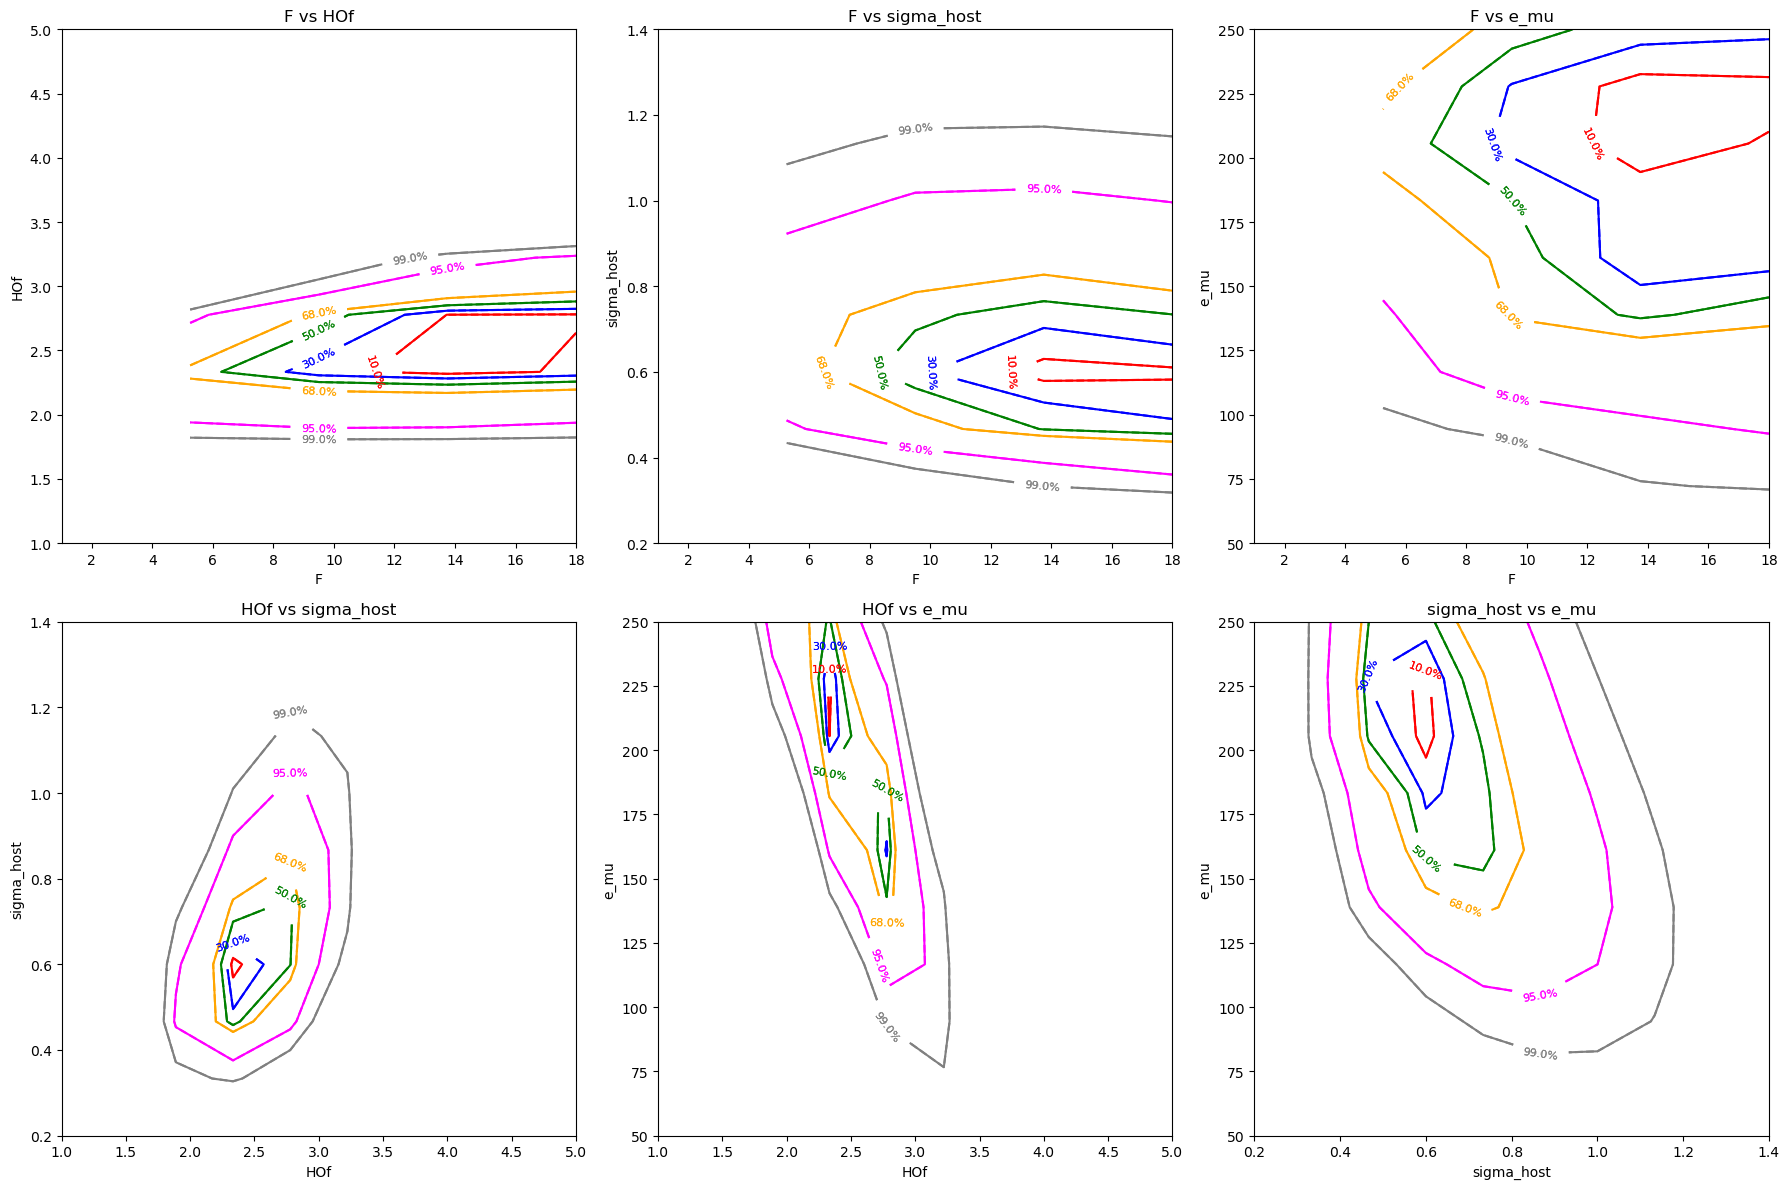

In [68]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "HOf", (2, 3), F_h, h_F),
    ("F", "sigma_host", (1, 3), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2), F_e_mu, e_mu_F),
    ("HOf", "sigma_host", (0, 3), h_sigma, sigma_h),
    ("HOf", "e_mu", (0, 2), h_e_mu, e_mu_h),
    ("sigma_host", "e_mu", (0, 1), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)
    
    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_fast, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'], linestyles='--')
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)    

plt.tight_layout()
plt.show()

C:\Users\klera\AppData\Local\Temp\ipykernel_23544\2399843331.py:25: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


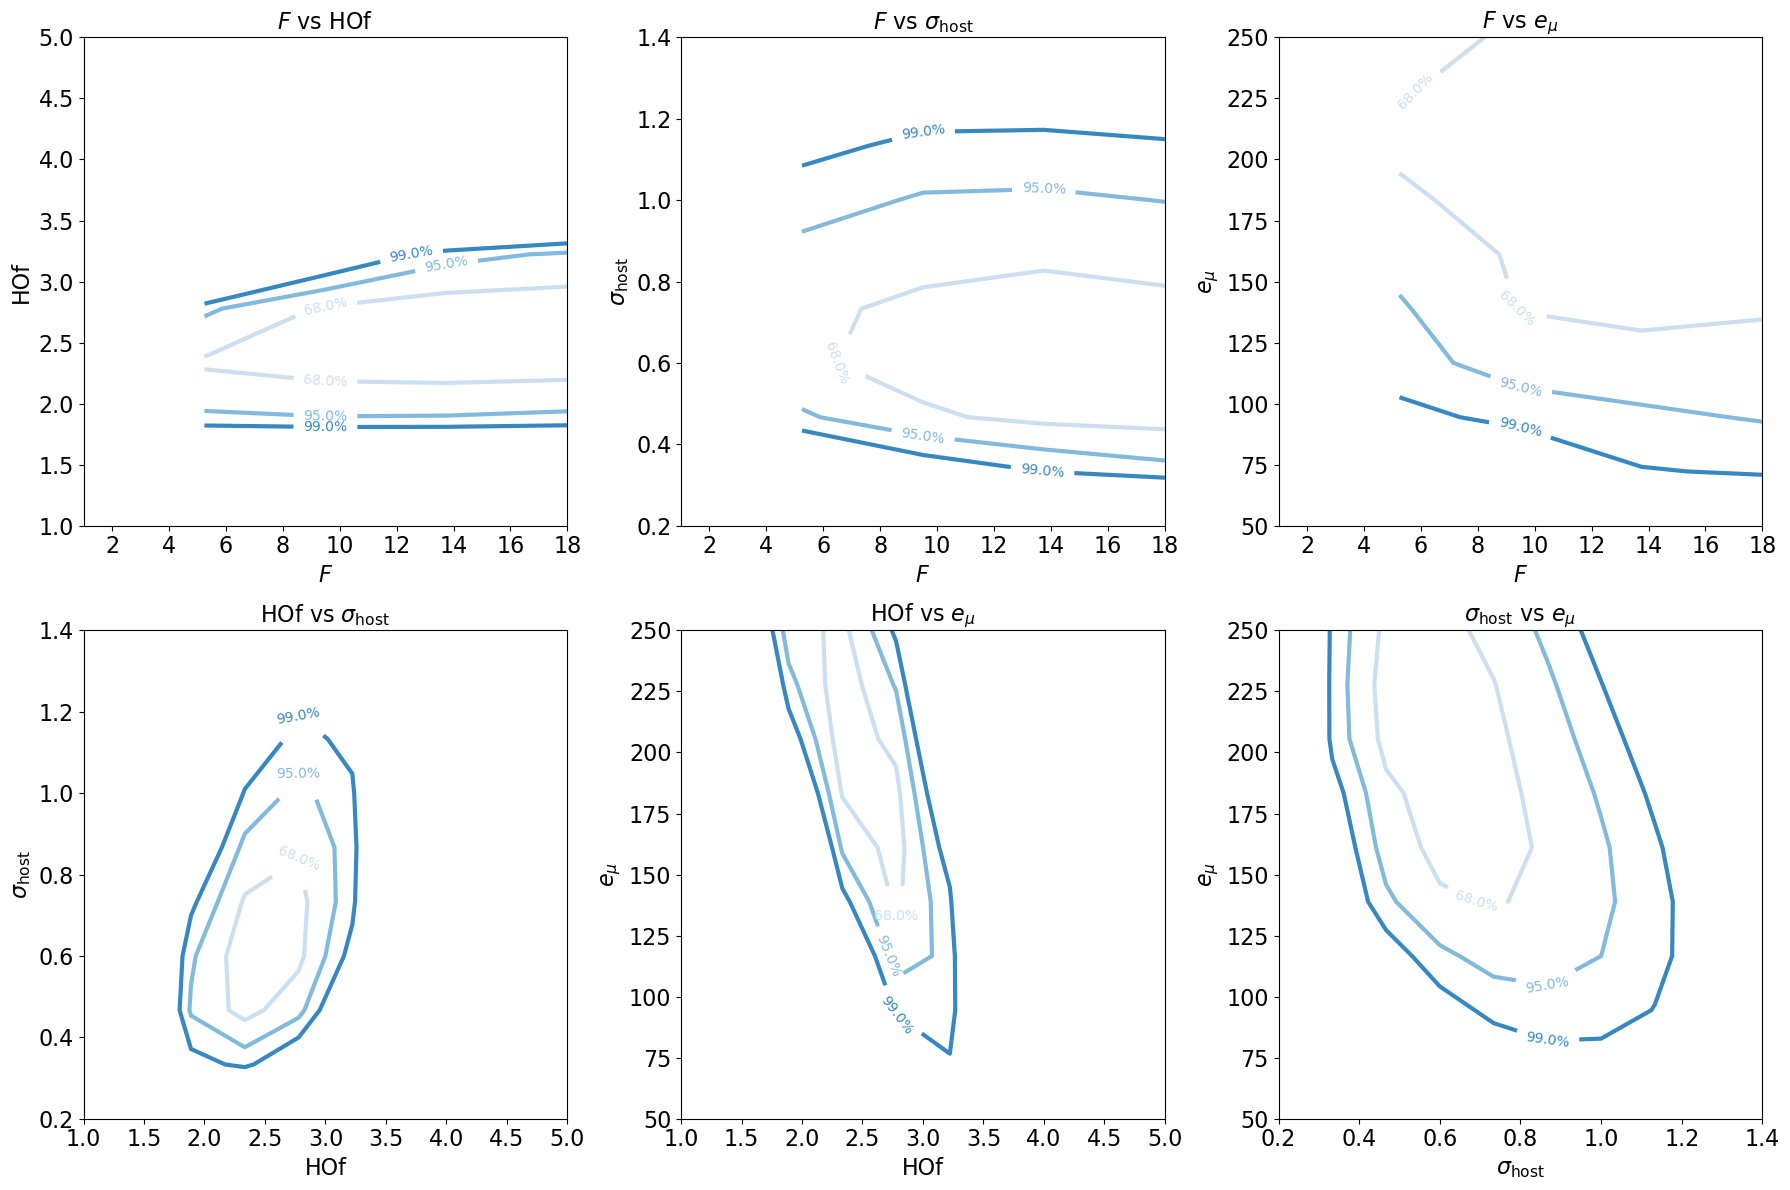

In [125]:
from scipy.stats import chi2

confidence_levels = [0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    (r"$F$", "HOf", (2, 3), F_h, h_F),
    (r"$F$", r"$\sigma_{\rm host}$", (1, 3), F_sigma, sigma_F),
    (r"$F$", r"$e_{\mu}$", (1, 2), F_e_mu, e_mu_F),
    ("HOf", r"$\sigma_{\rm host}$", (0, 3), h_sigma, sigma_h),
    ("HOf", r"$e_{\mu}$", (0, 2), h_e_mu, e_mu_h),
    (r"$\sigma_{\rm host}$", r"$e_{\mu}$", (0, 1), sigma_e_mu, e_mu_sigma)
]

blues = cm.get_cmap("Blues", 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
  
    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_fast, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    # cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g'], linestyles='--')
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=[blues(2), blues(4), blues(6)], extend='max', linewidths=3)
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=10)
    for label in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        # label.set_fontname('Arial')
        label.set_fontsize(16)

plt.tight_layout()
plt.show()

## Creating mock dataset

In order to check our analysis script, we create a mock dataset and try to recover the input parameters. We take the following steps:

1. Create a realistic redshift distribution of sources, similar to our real FRB dataset.
2. For each source, assign a ${\rm DM}_{\rm host}$ and ${\rm DM}_{\rm IGM}$.
3. To create these, we used fixed input parameters: $e_\mu, \sigma_\mu, D_{\rm var}, H_0, \Omega_b, f_{\rm IGM}$.
4. We recover $e_\mu, \sigma_\mu, D_{\rm var}, H_0 \Omega_b f_{\rm IGM}$.

In [85]:
## Number of mock values
N_mock_data = 10

**Step 1**: Redshift distribution

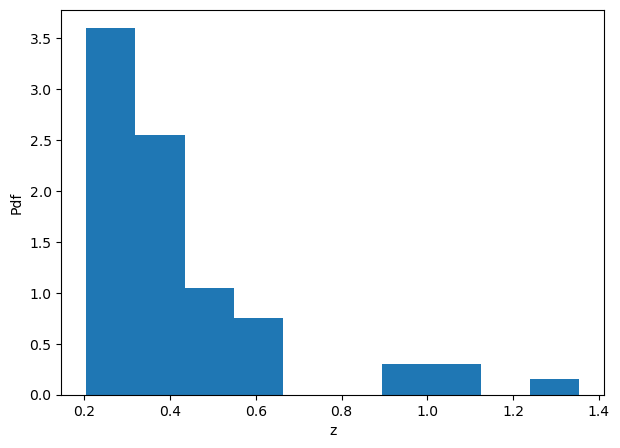

In [86]:
## Redshift histogram of real data
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

ax1.hist(frb_data_cut['z'], density=True)
ax1.set_xlabel('z')
ax1.set_ylabel('Pdf')

plt.show()

In [87]:
## We fit a KDE in the real data and draw z-samples from that

kde_z = gaussian_kde(frb_data_cut['z'])
z_high_res=np.linspace(np.floor(np.min(frb_data_cut['z'])), np.ceil(np.max(frb_data_cut['z'])), 100)
z_kde_values = kde_z(z_high_res)

## Mock z-values
z_kde_mock = kde_z.resample(size=N_mock_data)[0]

## Removing any very small-z samples,
## making sure that all mock redshifts satisfy the low-z cut performed in the original data
while np.min(z_kde_mock)<np.min(frb_data_cut['z']):
    bool_small_z = z_kde_mock < np.min(frb_data_cut['z'])
    z_kde_mock[bool_small_z] = kde_z.resample(size=np.sum(bool_small_z))[0]

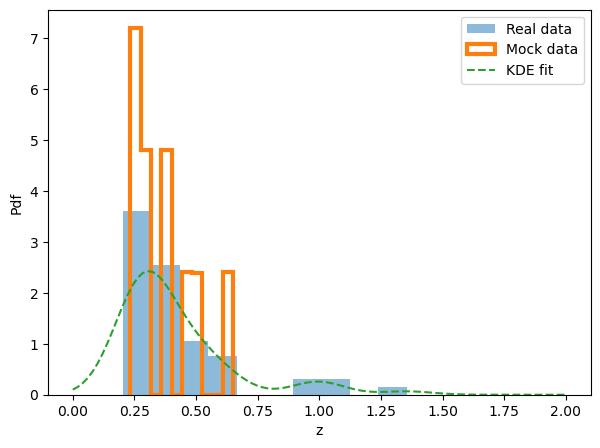

In [88]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

ax1.hist(frb_data_cut['z'], density=True, alpha=0.5, label='Real data')
ax1.hist(z_kde_mock, density=True, histtype='step', lw=3, label='Mock data')
ax1.plot(z_high_res, z_kde_values, ls='--', label='KDE fit')

ax1.set_xlabel('z')
ax1.set_ylabel('Pdf')

plt.legend()
plt.show()

**Steps 2 & 3**: Assign mock ${\rm DM}_{\rm host}$ and ${\rm DM}_{\rm IGM}$.

In [89]:
print(f"Mock H0Obf is: {round(HUBBLE*OMEGA_BARYONS*f_IGM, 2)}.")

e_mu_mock = 50
sigma_mu_mock = 0.5 
print(f"Mock e_mu is: {e_mu_mock}.")
print(f"Mock sigma_mu is: {sigma_mu_mock}.")

Mock H0Obf is: 2.78.
Mock e_mu is: 50.
Mock sigma_mu is: 0.5.


- DM_host

In [110]:
DM_host=np.linspace(0.01, 300, 500)
pdf_host = pdf_DM_host(DM_host, e_mu=e_mu_mock, sigma_host=sigma_mu_mock)

DM_mock_host = rng.choice(DM_host, size=N_mock_data, replace=True, p=normalise(pdf_host))

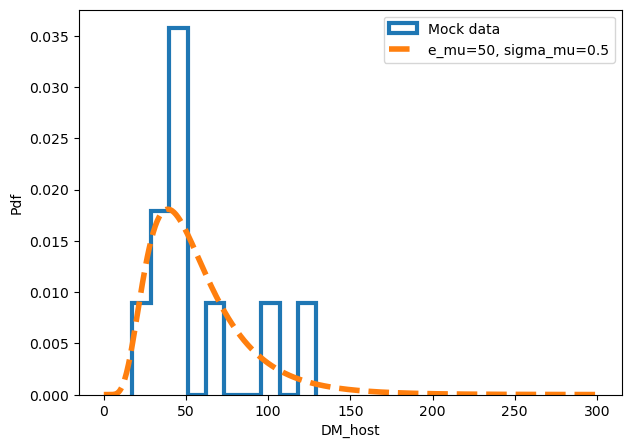

In [111]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

ax1.hist(DM_mock_host, density=True, histtype='step', lw=3, label='Mock data')
ax1.plot(DM_host, pdf_host, ls='--', lw=4, label='e_mu=50, sigma_mu=0.5')

ax1.set_xlabel('DM_host')
ax1.set_ylabel('Pdf')

plt.legend()
plt.show()

- DM_IGM

**MK**: Check the arbitraty +100 here

In [140]:
DM_theory_IGM = np.zeros_like(z_kde_mock)
DM_mock_IGM = np.zeros_like(z_kde_mock)

for idx, z in enumerate(z_kde_mock):   
    DM_theory_IGM[idx] = dispersion_measure(z_kde_mock[idx], H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, alpha=ALPHA_IGM, f_IGM_0 = f_IGM) #+100
    DM_mock_IGM[idx] = DM_theory_IGM[idx]+0*np.random.choice([-1, 1])*np.random.normal(0, 1e-1*DM_theory_IGM[idx])

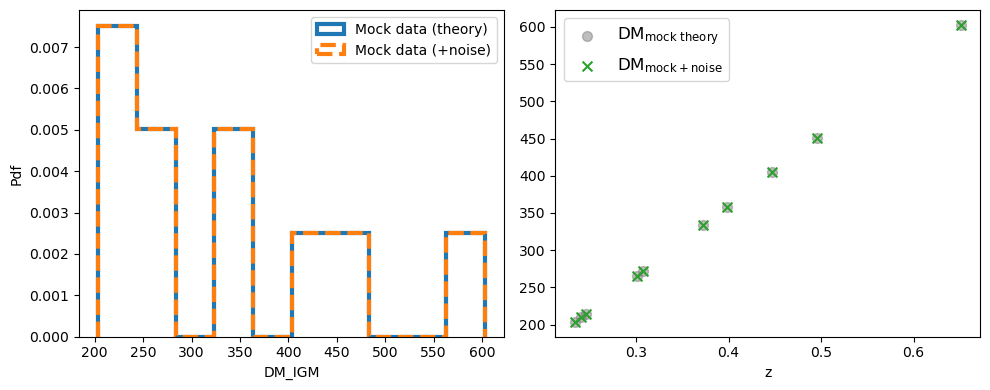

In [141]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.hist(DM_theory_IGM, density=True, histtype='step', lw=3, label='Mock data (theory)')
ax1.hist(DM_mock_IGM, density=True, histtype='step', lw=3, ls='--', label='Mock data (+noise)')
ax1.set_xlabel('DM_IGM')
ax1.set_ylabel('Pdf')
ax1.legend()

for idx, z in enumerate(z_kde_mock):
    ax2.scatter(z, DM_theory_IGM[idx], s=50, marker='o', c='tab:grey', label=r'DM$_{\rm mock\ theory}$', alpha=0.5)
    ax2.scatter(z, DM_mock_IGM[idx], s=50, marker='x', c='tab:green', label=r'DM$_{\rm mock +noise}$')
    
handles, labels = ax2.get_legend_handles_labels()
ax2.legend((labels[0], labels[1]), fontsize=12, loc = 'upper left')     
ax2.set_xlabel('z')
    
plt.tight_layout()
plt.show()

Adding also a quick ${\rm pdf}_{\rm IGM}$ fit, to figure out the input value for $D_{var}$.

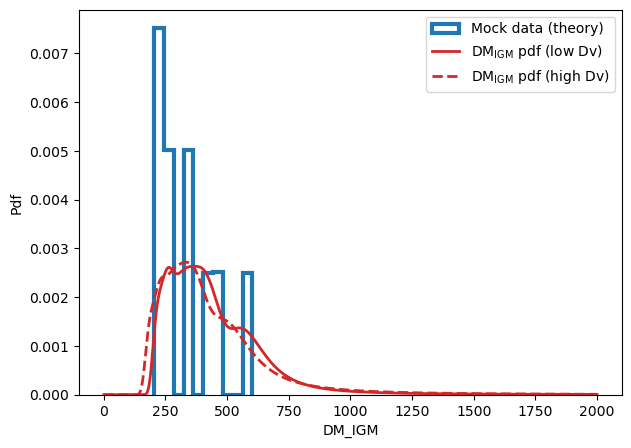

In [130]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

ax1.hist(DM_theory_IGM, density=True, histtype='step', lw=3, label='Mock data (theory)')

## The full range of DM_cosmic (the x-axis)
DM_cosmic_range = np.linspace(0.01, 2000, 2000)
pdf_all_lowDvar = np.zeros_like(DM_cosmic_range)
pdf_all_highDvar = np.zeros_like(DM_cosmic_range)

for idx, z in enumerate(z_kde_mock):
    sigma=sigma_var(np.sqrt(f_variance_delta(F=5.5, z=z)))
    C0 = find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3)    
    p=pdf_DM_cosmo(DM_cosmic_range/(100+DM_theory_IGM[idx]), C_0=C0, A=A, sigma=sigma)
    pdf_all_lowDvar += p
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F=15.5, z=z)))
    C0 = find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3)    
    p=pdf_DM_cosmo(DM_cosmic_range/(100+DM_theory_IGM[idx]), C_0=C0, A=A, sigma=sigma)
    pdf_all_highDvar += p    
    

ax1.plot(DM_cosmic_range, normalise(pdf_all_lowDvar), lw=2, ls='-', c='tab:red', label=r'DM$_{\rm IGM}$ pdf (low Dv)')
ax1.plot(DM_cosmic_range, normalise(pdf_all_highDvar), lw=2, ls='--', c='tab:red', label=r'DM$_{\rm IGM}$ pdf (high Dv)')


ax1.set_xlabel('DM_IGM')
ax1.set_ylabel('Pdf')

plt.legend()
plt.show()

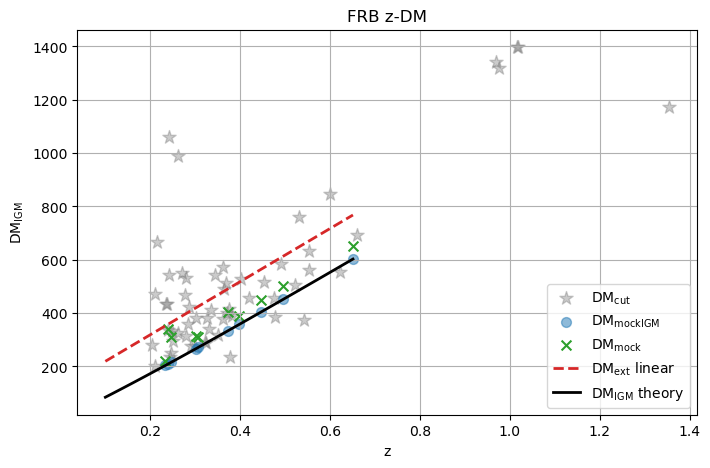

In [142]:
z_range = np.linspace(0.1, np.max(z_kde_mock), 100)
DM_theory = np.zeros_like(z_range)

DM_linear = slope_cut*z_range+intercept_cut

for idx, z in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, alpha=ALPHA_IGM, f_IGM_0 = f_IGM) #+100


fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

ax1.scatter(frb_data_cut['z'], frb_data_cut['DM_ext'], s=100, marker='*', label=r'DM$_{\rm cut}$', alpha=0.4, c='tab:grey')
ax1.scatter(z_kde_mock, DM_mock_IGM, s=50, marker='o', label=r'DM$_{\rm mock IGM}$', alpha=0.5)
ax1.scatter(z_kde_mock, DM_mock_IGM+DM_mock_host, s=50, marker='x', c='tab:green', label=r'DM$_{\rm mock}$')

ax1.plot(z_range, DM_linear, lw=2, ls='--', c='tab:red', label=r'DM$_{\rm ext}$ linear')
ax1.plot(z_range, DM_theory, lw=2, c='black', label=r'DM$_{\rm IGM}$ theory')


ax1.set_xlabel('z')
ax1.set_ylabel(r'DM$_{\rm IGM}$')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

Adding everything in a dataframe, like the original data:

In [143]:
mock_data = pd.DataFrame()

mock_data['z'] = z_kde_mock
mock_data['DM_ext'] = DM_mock_IGM #+DM_mock_host/(1+z_kde_mock)

# ## Perform the original redshift cut
# mock_data = mock_data[mock_data['z'] >= 0.2]

## Add FRB column (to be consistent with analysis script)
mock_data['FRB'] = np.arange(len(mock_data))

Mock data set:

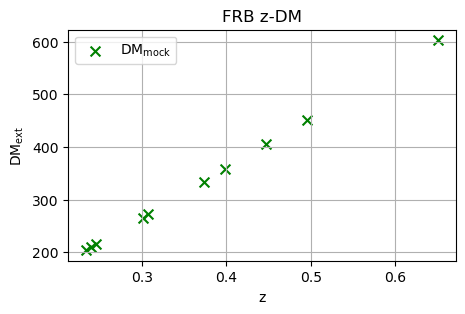

In [144]:
fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot(111)

ax1.scatter(mock_data['z'], mock_data['DM_ext'], s=50, marker='x', label=r'DM$_{\rm mock}$', c='green')

ax1.set_xlabel('z')
ax1.set_ylabel(r'DM$_{\rm ext}$')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

Create dataframe of true values

In [115]:
true_values = pd.DataFrame()

true_values[r"$\sigma_{\rm host}$"] = np.array([sigma_mu_mock])
true_values[r"$D_v$"] = np.array([5.5])
true_values['HOf'] = np.array(HUBBLE*OMEGA_BARYONS*f_IGM)
true_values[r"$e_{\mu}$"] = np.array(e_mu_mock)

In [116]:
true_values

,$\sigma_{\rm host}$,$D_v$,HOf,$e_{\mu}$
0,0.5,5.5,2.783181,50


**Steps 4**: Recovering true values.

Creating the grid of parameters

In [134]:
HOf_array=np.linspace(1.0, 6.0, 8)
Dv_array=np.linspace(3.0, 15.0, 10)
sigma_host_array=np.linspace(0.1, 1.0, 8)
e_mu_array=np.linspace(25, 75, 8)

Dv_4D, HOf_array_4D, sigma_host_4D, e_mu_4D = np.meshgrid(
    Dv_array, HOf_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

Dv_h, h_Dv = np.meshgrid(Dv_array, HOf_array)
Dv_sigma, sigma_Dv = np.meshgrid(Dv_array, sigma_host_array)
Dv_e_mu, e_mu_Dv = np.meshgrid(Dv_array, e_mu_array)
h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)
sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of Dv_4D: {Dv_4D.shape},\
      HOf_array_4D: {HOf_array_4D.shape},\
      sigma_host_4D: {sigma_host_4D.shape},\
      e_mu_4D: {e_mu_4D.shape}')

print(fr'Shape of Dv_h: {Dv_h.shape},\
      h_Dv: {h_Dv.shape},\
      Dv_sigma: {Dv_sigma.shape},\
      sigma_Dv: {sigma_Dv.shape},\
      Dv_e_mu: {Dv_e_mu.shape},\
      e_mu_Dv: {e_mu_Dv.shape}')

Shape of Dv_4D: (10, 8, 8, 8),\
      HOf_array_4D: (10, 8, 8, 8),\
      sigma_host_4D: (10, 8, 8, 8),\
      e_mu_4D: (10, 8, 8, 8)
Shape of Dv_h: (8, 10),\
      h_Dv: (8, 10),\
      Dv_sigma: (8, 10),\
      sigma_Dv: (8, 10),\
      Dv_e_mu: (8, 10),\
      e_mu_Dv: (8, 10)


In [145]:
log_posterior_4D = np.zeros_like(Dv_4D, dtype= np.float64)
total_iterations = len(mock_data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (Dv, HOf, sigma_host, e_mu)
    for Dv in Dv_array
    for HOf in HOf_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in mock_data.iterrows():
    # Iterate through parameter combinations
    for idx, (Dv, HOf, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_fast(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=Dv,
            HOf=HOf,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        
        # Calculate indices for 4D array
        i = idx // (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        l = idx % len(e_mu_array)
    
        # Store result
        if prob > 0:
            log_posterior_4D[i,j,k,l] += np.log(prob)
        else:
            log_posterior_4D[i,j,k,l] = -np.inf
        
        # Update progress bar
        pbar.update(1)
    
        # Optional: Add parameter values to progress bar description
        pbar.set_description(f"idx={_}, FRB={row['FRB']}, z={row['z']:.2f}, Dv={Dv:.2f}, HOf={HOf:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}, prob={prob:.2f}")
    
    # # log_posterior = np.log(posterior_4D)
    log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
    if np.isfinite(log_sum):
        log_posterior_4D = log_posterior_4D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

FRB=9.0: : 51210it [06:16, 135.92it/s]                                                                                 


In [146]:
log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
if np.isfinite(log_sum):
    posterior_4D_mock = np.exp(log_posterior_4D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

# np.save("../../Data/posterior/posterior_4D_mean_sqrt_mock_data_set.npy", posterior_4D)

In [43]:
# posterior_4D_mock = np.load("../../Data/posterior/posterior_4D_mean_sqrt_mock_data_set.npy")

C:\Users\klera\AppData\Local\Temp\ipykernel_21304\294806082.py:23: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


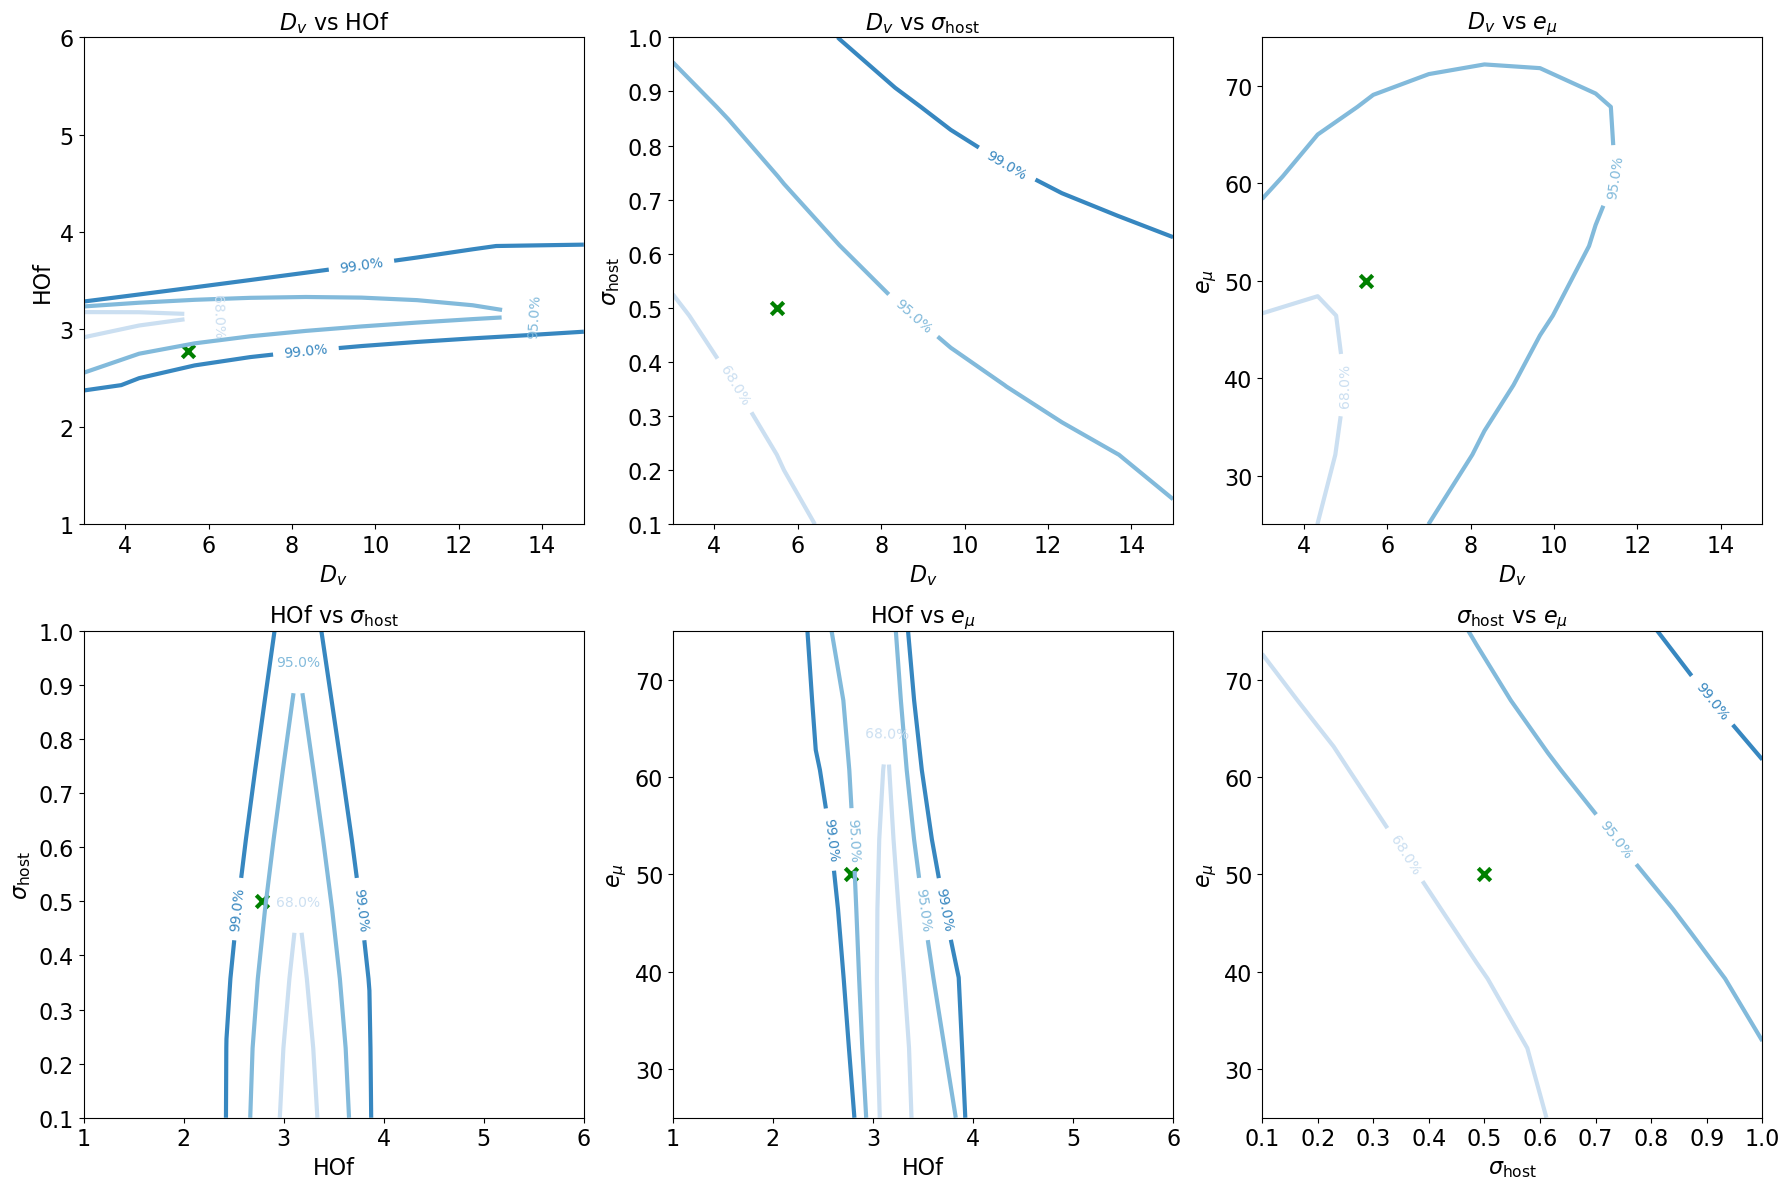

In [147]:
confidence_levels = [0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    (r"$D_v$", "HOf", (2, 3), Dv_h, h_Dv),
    (r"$D_v$", r"$\sigma_{\rm host}$", (1, 3), Dv_sigma, sigma_Dv),
    (r"$D_v$", r"$e_{\mu}$", (1, 2), Dv_e_mu, e_mu_Dv),
    ("HOf", r"$\sigma_{\rm host}$", (0, 3), h_sigma, sigma_h),
    ("HOf", r"$e_{\mu}$", (0, 2), h_e_mu, e_mu_h),
    (r"$\sigma_{\rm host}$", r"$e_{\mu}$", (0, 1), sigma_e_mu, e_mu_sigma)
]

blues = cm.get_cmap("Blues", 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
  
    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_mock, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    # cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g'], linestyles='--')
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=[blues(2), blues(4), blues(6)], extend='max', linewidths=3)
    ax.scatter(true_values[f'{x_var}'], true_values[f'{y_var}'], s=80, marker='x', lw=3, label=r'DM$_{\rm kde}$', c='green')
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=10)
    for label in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        # label.set_fontname('Arial')
        label.set_fontsize(16)

plt.tight_layout()
plt.show()

# Gaussian pdfs

## 1. Mock data

In [26]:
## Number of mock values
N_mock_data = 30

In [27]:
## We fit a KDE in the real data and draw z-samples from that

kde_z = gaussian_kde(frb_data_cut['z'])
z_high_res=np.linspace(np.floor(np.min(frb_data_cut['z'])), np.ceil(np.max(frb_data_cut['z'])), 100)
z_kde_values = kde_z(z_high_res)

## Mock z-values
z_kde_mock = kde_z.resample(size=N_mock_data)[0]

## Removing any very small-z samples,
## making sure that all mock redshifts satisfy the low-z cut performed in the original data
while np.min(z_kde_mock)<np.min(frb_data_cut['z']):
    bool_small_z = z_kde_mock < np.min(frb_data_cut['z'])
    z_kde_mock[bool_small_z] = kde_z.resample(size=np.sum(bool_small_z))[0]

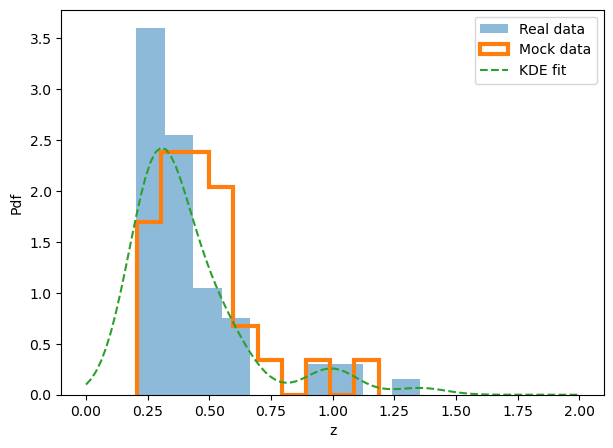

In [28]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

ax1.hist(frb_data_cut['z'], density=True, alpha=0.5, label='Real data')
ax1.hist(z_kde_mock, density=True, histtype='step', lw=3, label='Mock data')
ax1.plot(z_high_res, z_kde_values, ls='--', label='KDE fit')

ax1.set_xlabel('z')
ax1.set_ylabel('Pdf')

plt.legend()
plt.show()

**Steps 2 & 3**: Assign mock ${\rm DM}_{\rm host}$ and ${\rm DM}_{\rm IGM}$.

**MK**: Try fixing $DM_h$ to a constant value, or similarly take $\sigma_h \rightarrow 0$.

In [29]:
print(f"Mock H0Obf is: {round(HUBBLE*OMEGA_BARYONS*f_IGM, 2)}.")

DM_mu_host = 100
A_host_mock = 0.05
A_diff_mock = 0.1

print(f"Mock DM_host is: {DM_mu_host}.")
print(f"Mock A_host is: {A_host_mock}.")
print(f"Mock A_diff is: {A_diff_mock}.")

Mock H0Obf is: 2.78.
Mock DM_host is: 100.
Mock A_host is: 0.05.
Mock A_diff is: 0.1.


In [30]:
## Host DMs
DM_mock_host = rng.normal(loc=DM_mu_host, scale=A_host_mock*DM_mu_host, size=N_mock_data)

## IGM DMs
DM_theory_IGM = np.zeros_like(z_kde_mock)
DM_mock_IGM = np.zeros_like(z_kde_mock)
for idx, z in enumerate(z_kde_mock):   
    DM_theory_IGM[idx] = dispersion_measure(z_kde_mock[idx], H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, alpha=ALPHA_IGM, f_IGM_0 = f_IGM)
    DM_mock_IGM[idx] = rng.normal(loc=DM_theory_IGM[idx], scale=A_diff_mock*DM_theory_IGM[idx], size=1)

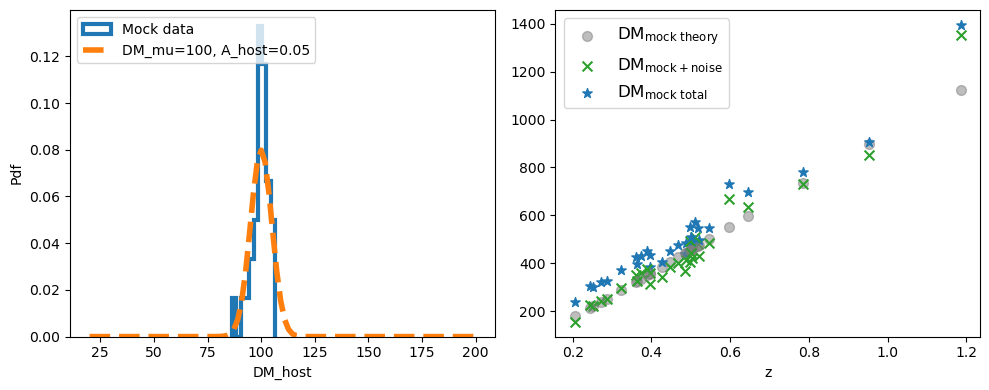

In [36]:
DM_host_array = np.linspace(20, 200, 100)
DM_diff_array = np.linspace(20, 700, 300)


fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.hist(DM_mock_host, density=True, histtype='step', lw=3, label='Mock data')
ax1.plot(DM_host_array, Gaussian(DM_host_array, DM_mu_host, A_host_mock*DM_mu_host),\
         ls='--', lw=4, label=f'DM_mu={DM_mu_host}, A_host={A_host_mock}')
ax1.set_xlabel('DM_host')
ax1.set_ylabel('Pdf')
ax1.legend(loc='upper left', fontsize=10)

for idx, z in enumerate(z_kde_mock):
    ax2.scatter(z, DM_theory_IGM[idx], s=50, marker='o', c='tab:grey', label=r'DM$_{\rm mock\ theory}$', alpha=0.5)
    ax2.scatter(z, DM_mock_IGM[idx], s=50, marker='x', c='tab:green', label=r'DM$_{\rm mock +noise}$')
    ax2.scatter(z, DM_mock_IGM[idx]+DM_mock_host[idx]/(1+z), s=50, marker='*', c='tab:blue', label=r'DM$_{\rm mock\ total}$')
    
handles, labels = ax2.get_legend_handles_labels()
ax2.legend((labels[0], labels[1], labels[2]), fontsize=12, loc = 'upper left')     
ax2.set_xlabel('z')

plt.tight_layout()
plt.show()

In [37]:
mock_data = pd.DataFrame()

mock_data['z'] = z_kde_mock
mock_data['DM_ext'] = DM_mock_IGM+DM_mock_host/(1+z_kde_mock)

## Add FRB column (to be consistent with analysis script)
mock_data['FRB'] = np.arange(len(mock_data))

In [38]:
true_values = pd.DataFrame()

true_values[r"$A_{\rm host}$"] = np.array([A_host_mock])
true_values[r"$A_{\rm diff}$"] = np.array([A_diff_mock])
true_values['HOf'] = np.array([HUBBLE*OMEGA_BARYONS*f_IGM])
true_values[r"$DM_{\rm host}$"] = np.array([DM_mu_host])

In [39]:
true_values

,$A_{\rm host}$,$A_{\rm diff}$,HOf,$DM_{\rm host}$
0,0.05,0.1,2.783181,100


In [40]:
HOf_array=np.linspace(1.0, 4.0, 10)
A_diff_array=np.linspace(0.05, 0.2, 10)
A_host_array=np.linspace(0.01, 0.1, 10)
DM_mu_array=np.linspace(90, 110, 10)

A_diff_4D, HOf_array_4D, A_host_4D, DM_mu_4D = np.meshgrid(
    A_diff_array, HOf_array, A_host_array, DM_mu_array,
    indexing='ij'
    )

A_diff_h, h_A_diff = np.meshgrid(A_diff_array, HOf_array)
A_diff_A_host, A_host_A_diff = np.meshgrid(A_diff_array, A_host_array)
A_diff_DM_mu, DM_mu_A_diff = np.meshgrid(A_diff_array, DM_mu_array)
h_A_host, A_host_h = np.meshgrid(HOf_array, A_host_array)
h_DM_mu, DM_mu_h = np.meshgrid(HOf_array, DM_mu_array)
A_host_DM_mu, DM_mu_A_host = np.meshgrid(A_host_array, DM_mu_array)

print(fr'Shape of A_diff_4D: {A_diff_4D.shape},\
      HOf_array_4D: {HOf_array_4D.shape},\
      A_host_4D: {A_host_4D.shape},\
      DM_mu_4D: {DM_mu_4D.shape}')

print(fr'Shape of A_diff_h: {A_diff_h.shape},\
      h_A_diff: {h_A_diff.shape},\
      A_diff_A_host: {A_diff_A_host.shape},\
      A_host_A_diff: {A_host_A_diff.shape},\
      A_diff_DM_mu: {A_diff_DM_mu.shape},\
      DM_mu_A_diff: {DM_mu_A_diff.shape}')

Shape of A_diff_4D: (10, 10, 10, 10),\
      HOf_array_4D: (10, 10, 10, 10),\
      A_host_4D: (10, 10, 10, 10),\
      DM_mu_4D: (10, 10, 10, 10)
Shape of A_diff_h: (10, 10),\
      h_A_diff: (10, 10),\
      A_diff_A_host: (10, 10),\
      A_host_A_diff: (10, 10),\
      A_diff_DM_mu: (10, 10),\
      DM_mu_A_diff: (10, 10)


In [41]:
log_posterior_4D = np.zeros_like(A_diff_4D, dtype= np.float64)
total_iterations = len(mock_data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (A_diff, HOf, A_host, DM_mu)
    for A_diff in A_diff_array
    for HOf in HOf_array
    for A_host in A_host_array
    for DM_mu in DM_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in mock_data.iterrows():
    # Iterate through parameter combinations
    for idx, (A_diff, HOf, A_host, DM_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_gauss_convo(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            HOf=HOf,
            A_diff=A_diff,
            DM_mu_host=DM_mu,
            A_host=A_host
        )
        
        # Calculate indices for 4D array
        i = idx // (len(HOf_array) * len(A_host_array) * len(DM_mu_array))
        j = (idx % (len(HOf_array) * len(A_host_array) * len(DM_mu_array))) // (len(A_host_array) * len(DM_mu_array))
        k = (idx % (len(A_host_array) * len(DM_mu_array))) // len(DM_mu_array)
        l = idx % len(DM_mu_array)
    
        # Store result
        if prob > 0:
            log_posterior_4D[i,j,k,l] += np.log(prob)
        else:
            log_posterior_4D[i,j,k,l] = -np.inf
        
        # Update progress bar
        pbar.update(1)
    
        # Optional: Add parameter values to progress bar description
        pbar.set_description(f"idx={_}, FRB={row['FRB']}, z={row['z']:.2f}, A_diff={A_diff:.2f}, HOf={HOf:.2f}, A_host={A_host:.2f}, DM_mu={DM_mu:.2f}, prob={prob:.2f}")
    
    # # log_posterior = np.log(posterior_4D)
    log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
    if np.isfinite(log_sum):
        log_posterior_4D = log_posterior_4D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
    
    # pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

FRB=29.0: : 300000it [06:02, 826.95it/s]                                                                               


In [42]:
log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
if np.isfinite(log_sum):
    posterior_4D_mock = np.exp(log_posterior_4D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("../../Data/posterior/posterior_4D_mean_sqrt_gauss_mock_data_set.npy", posterior_4D_mock)

In [43]:
# posterior_4D_mock = np.load("../../Data/posterior/posterior_4D_mean_sqrt_gauss_mock_data_set.npy")

C:\Users\klera\AppData\Local\Temp\ipykernel_17004\2322800372.py:23: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


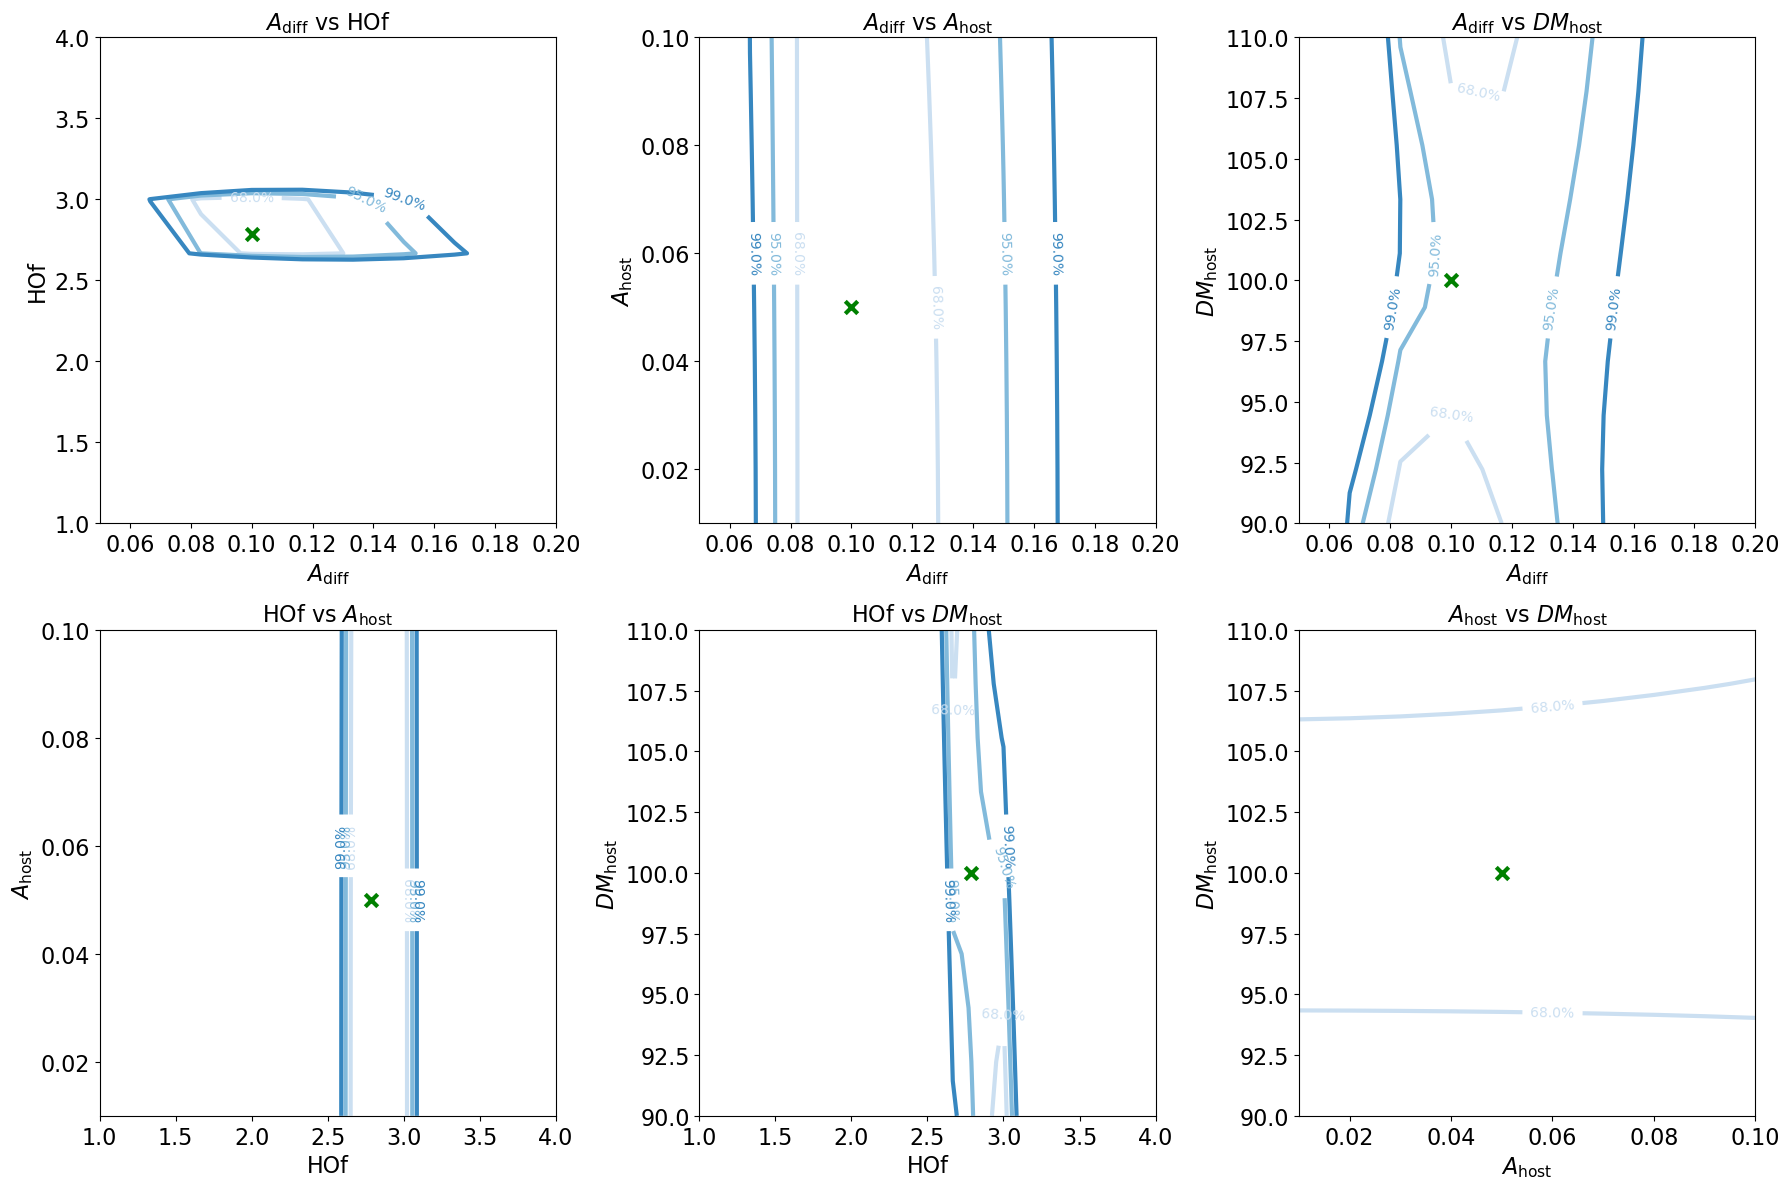

In [44]:
confidence_levels = [0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    (r"$A_{\rm diff}$", "HOf", (2, 3), A_diff_h, h_A_diff),
    (r"$A_{\rm diff}$", r"$A_{\rm host}$", (1, 3), A_diff_A_host, A_host_A_diff),
    (r"$A_{\rm diff}$", r"$DM_{\rm host}$", (1, 2), A_diff_DM_mu, DM_mu_A_diff),
    ("HOf", r"$A_{\rm host}$", (0, 3), h_A_host, A_host_h),
    ("HOf", r"$DM_{\rm host}$", (0, 2), h_DM_mu, DM_mu_h),
    (r"$A_{\rm host}$", r"$DM_{\rm host}$", (0, 1), A_host_DM_mu, DM_mu_A_host)
]

blues = cm.get_cmap("Blues", 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
  
    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_mock, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    # cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g'], linestyles='--')
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=[blues(2), blues(4), blues(6)], extend='max', linewidths=3)
    ax.scatter(true_values[f'{x_var}'], true_values[f'{y_var}'], s=80, marker='x', lw=3, label=r'DM$_{\rm kde}$', c='green')
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=10)
    for label in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        # label.set_fontname('Arial')
        label.set_fontsize(16)

plt.tight_layout()
plt.show()

## 2. Real data

In [60]:
HOf_array=np.linspace(1.0, 6.0, 8)
A_diff_array=np.linspace(0.01, 0.2, 8)
A_host_array=np.linspace(0.01, 0.2, 8)
DM_mu_array=np.linspace(25, 75, 8)

A_diff_4D, HOf_array_4D, A_host_4D, DM_mu_4D = np.meshgrid(
    A_diff_array, HOf_array, A_host_array, DM_mu_array,
    indexing='ij'
    )

A_diff_h, h_A_diff = np.meshgrid(A_diff_array, HOf_array)
A_diff_A_host, A_host_A_diff = np.meshgrid(A_diff_array, A_host_array)
A_diff_DM_mu, DM_mu_A_diff = np.meshgrid(A_diff_array, DM_mu_array)
h_A_host, A_host_h = np.meshgrid(HOf_array, A_host_array)
h_DM_mu, DM_mu_h = np.meshgrid(HOf_array, DM_mu_array)
A_host_DM_mu, DM_mu_A_host = np.meshgrid(A_host_array, DM_mu_array)

print(fr'Shape of A_diff_4D: {A_diff_4D.shape},\
      HOf_array_4D: {HOf_array_4D.shape},\
      A_host_4D: {A_host_4D.shape},\
      DM_mu_4D: {DM_mu_4D.shape}')

print(fr'Shape of A_diff_h: {A_diff_h.shape},\
      h_A_diff: {h_A_diff.shape},\
      A_diff_A_host: {A_diff_A_host.shape},\
      A_host_A_diff: {A_host_A_diff.shape},\
      A_diff_DM_mu: {A_diff_DM_mu.shape},\
      DM_mu_A_diff: {DM_mu_A_diff.shape}')

Shape of A_diff_4D: (8, 8, 8, 8),\
      HOf_array_4D: (8, 8, 8, 8),\
      A_host_4D: (8, 8, 8, 8),\
      DM_mu_4D: (8, 8, 8, 8)
Shape of A_diff_h: (8, 8),\
      h_A_diff: (8, 8),\
      A_diff_A_host: (8, 8),\
      A_host_A_diff: (8, 8),\
      A_diff_DM_mu: (8, 8),\
      DM_mu_A_diff: (8, 8)


In [66]:
frb_data_cut.iterrows()

<generator object DataFrame.iterrows at 0x0000018E66F06890>

In [61]:
log_posterior_4D = np.zeros_like(A_diff_4D, dtype= np.float64)
total_iterations = len(frb_data_cut['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (A_diff, HOf, A_host, DM_mu)
    for A_diff in A_diff_array
    for HOf in HOf_array
    for A_host in A_host_array
    for DM_mu in DM_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in frb_data_cut.iterrows():
    # Iterate through parameter combinations
    for idx, (A_diff, HOf, A_host, DM_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_gauss(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            HOf=HOf,
            A_diff=A_diff,
            DM_mu_host=DM_mu,
            A_host=A_host
        )
        
        # Calculate indices for 4D array
        i = idx // (len(HOf_array) * len(A_host_array) * len(DM_mu_array))
        j = (idx % (len(HOf_array) * len(A_host_array) * len(DM_mu_array))) // (len(A_host_array) * len(DM_mu_array))
        k = (idx % (len(A_host_array) * len(DM_mu_array))) // len(DM_mu_array)
        l = idx % len(DM_mu_array)
    
        # Store result
        if prob > 0:
            log_posterior_4D[i,j,k,l] += np.log(prob)
        else:
            log_posterior_4D[i,j,k,l] = -np.inf
        
        # Update progress bar
        pbar.update(1)
    
        # Optional: Add parameter values to progress bar description
        pbar.set_description(f"idx={_}, FRB={row['FRB']}, z={row['z']:.2f}, A_diff={A_diff:.2f}, HOf={HOf:.2f}, A_host={A_host:.2f}, DM_mu={DM_mu:.2f}, prob={prob:.2f}")
    
    # # log_posterior = np.log(posterior_4D)
    log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
    if np.isfinite(log_sum):
        log_posterior_4D = log_posterior_4D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

FRB=FRB 20231025B: : 237626it [06:50, 579.51it/s]                                                                             


In [62]:
log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
if np.isfinite(log_sum):
    posterior_4D = np.exp(log_posterior_4D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("../../Data/posterior/posterior_4D_mean_sqrt_gauss_data_set.npy", posterior_4D)

In [57]:
# posterior_4D_mock = np.load("../../Data/posterior/posterior_4D_mean_sqrt_gauss_mock_data_set.npy")

C:\Users\klera\AppData\Local\Temp\ipykernel_22344\1460136035.py:23: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


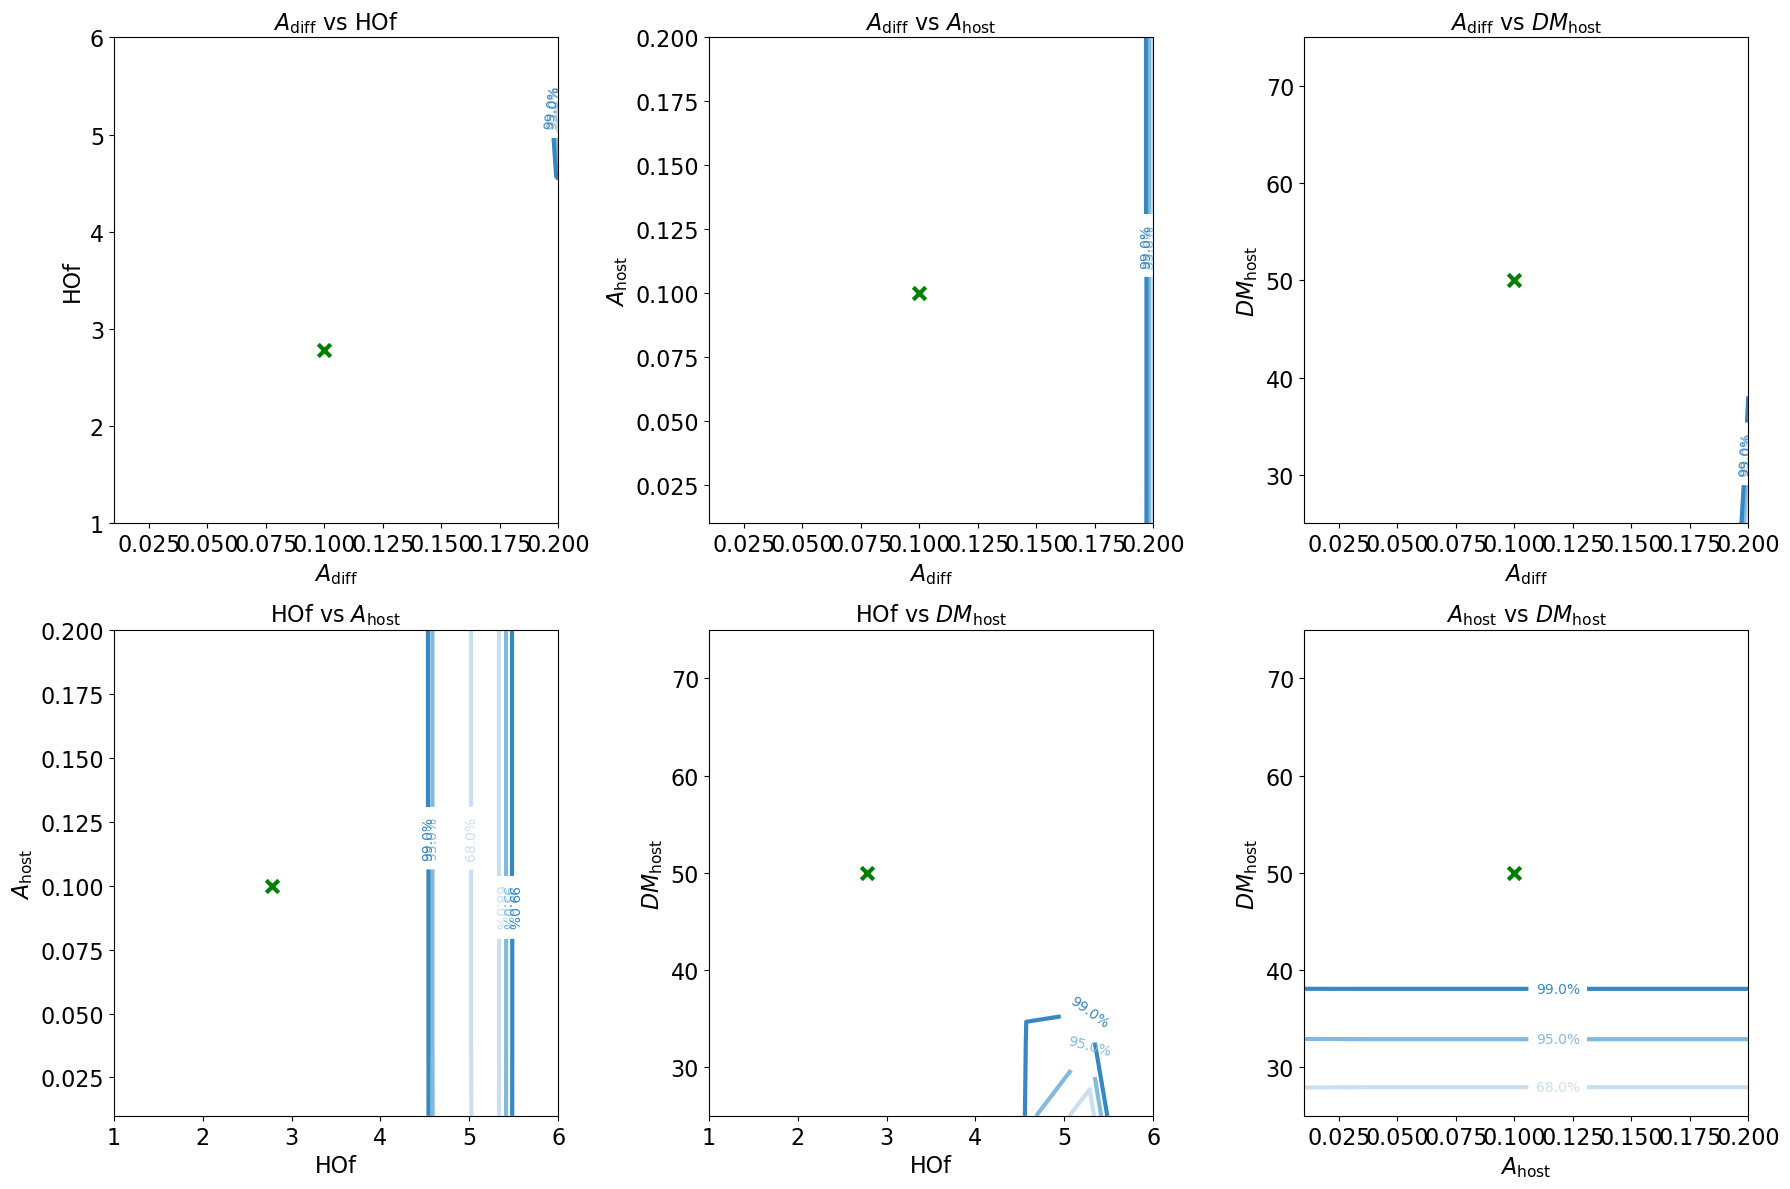

In [63]:
confidence_levels = [0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    (r"$A_{\rm diff}$", "HOf", (2, 3), A_diff_h, h_A_diff),
    (r"$A_{\rm diff}$", r"$A_{\rm host}$", (1, 3), A_diff_A_host, A_host_A_diff),
    (r"$A_{\rm diff}$", r"$DM_{\rm host}$", (1, 2), A_diff_DM_mu, DM_mu_A_diff),
    ("HOf", r"$A_{\rm host}$", (0, 3), h_A_host, A_host_h),
    ("HOf", r"$DM_{\rm host}$", (0, 2), h_DM_mu, DM_mu_h),
    (r"$A_{\rm host}$", r"$DM_{\rm host}$", (0, 1), A_host_DM_mu, DM_mu_A_host)
]

blues = cm.get_cmap("Blues", 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
  
    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    # cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g'], linestyles='--')
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=[blues(2), blues(4), blues(6)], extend='max', linewidths=3)
    ax.scatter(true_values[f'{x_var}'], true_values[f'{y_var}'], s=80, marker='x', lw=3, label=r'DM$_{\rm kde}$', c='green')
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=10)
    for label in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        # label.set_fontname('Arial')
        label.set_fontsize(16)

plt.tight_layout()
plt.show()

# Analysis of Macquart+ 2020 data

In [19]:
data_Macq=pd.read_csv('../../Data/FRB_Macquart_org.csv')
data_Macq=data_Macq.drop(columns=['DM'])
data_Macq

,FRB,z,DM_ext
0,FRB 20180924,0.3214,281.42
1,FRB 20181112,0.4755,509.27
2,FRB 20190102,0.2910,283.60
3,FRB 20190608,0.1178,258.70
4,FRB 20190711,0.5220,513.10


In [20]:
HOf_array=np.linspace(1.0, 6.0, 8)
Dv_array=np.linspace(3.0, 15.0, 10)
sigma_host_array=np.linspace(0.1, 1.0, 8)
e_mu_array=np.linspace(25, 75, 8)

Dv_4D, HOf_array_4D, sigma_host_4D, e_mu_4D = np.meshgrid(
    Dv_array, HOf_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

Dv_h, h_Dv = np.meshgrid(Dv_array, HOf_array)
Dv_sigma, sigma_Dv = np.meshgrid(Dv_array, sigma_host_array)
Dv_e_mu, e_mu_Dv = np.meshgrid(Dv_array, e_mu_array)
h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)
sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of Dv_4D: {Dv_4D.shape},\
      HOf_array_4D: {HOf_array_4D.shape},\
      sigma_host_4D: {sigma_host_4D.shape},\
      e_mu_4D: {e_mu_4D.shape}')

print(fr'Shape of Dv_h: {Dv_h.shape},\
      h_Dv: {h_Dv.shape},\
      Dv_sigma: {Dv_sigma.shape},\
      sigma_Dv: {sigma_Dv.shape},\
      Dv_e_mu: {Dv_e_mu.shape},\
      e_mu_Dv: {e_mu_Dv.shape}')

Shape of Dv_4D: (10, 8, 8, 8),\
      HOf_array_4D: (10, 8, 8, 8),\
      sigma_host_4D: (10, 8, 8, 8),\
      e_mu_4D: (10, 8, 8, 8)
Shape of Dv_h: (8, 10),\
      h_Dv: (8, 10),\
      Dv_sigma: (8, 10),\
      sigma_Dv: (8, 10),\
      Dv_e_mu: (8, 10),\
      e_mu_Dv: (8, 10)


In [31]:
log_posterior_4D = np.zeros_like(Dv_4D, dtype= np.float64)
total_iterations = len(data_Macq['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (Dv, HOf, sigma_host, e_mu)
    for Dv in Dv_array
    for HOf in HOf_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in data_Macq.iterrows():
    # Iterate through parameter combinations
    for idx, (Dv, HOf, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_fast(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=Dv,
            HOf=HOf,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        
        # Calculate indices for 4D array
        i = idx // (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        l = idx % len(e_mu_array)
    
        # Store result
        if prob > 0:
            log_posterior_4D[i,j,k,l] += np.log(prob)
        else:
            log_posterior_4D[i,j,k,l] = -np.inf
        
        # Update progress bar
        # pbar.update(1)
    
        # Optional: Add parameter values to progress bar description
        pbar.set_description(f"idx={_}, FRB={row['FRB']}, z={row['z']:.2f}, Dv={Dv:.2f}, HOf={HOf:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}, prob={prob:.2f}")
    
    # # log_posterior = np.log(posterior_4D)
    log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
    if np.isfinite(log_sum):
        log_posterior_4D = log_posterior_4D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
    
    # pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

FRB=FRB 20190711:   0%|                                                                          | 0/5 [02:26<?, ?it/s]


In [32]:
log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
if np.isfinite(log_sum):
    posterior_4D_mock = np.exp(log_posterior_4D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

C:\Users\klera\AppData\Local\Temp\ipykernel_17536\1916848325.py:23: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
C:\Users\klera\AppData\Local\Temp\ipykernel_17536\1916848325.py:28: UserWarning: No contour levels were found within the data range.
  cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=[blues(2), blues(4), blues(6)], extend='max', linewidths=3)


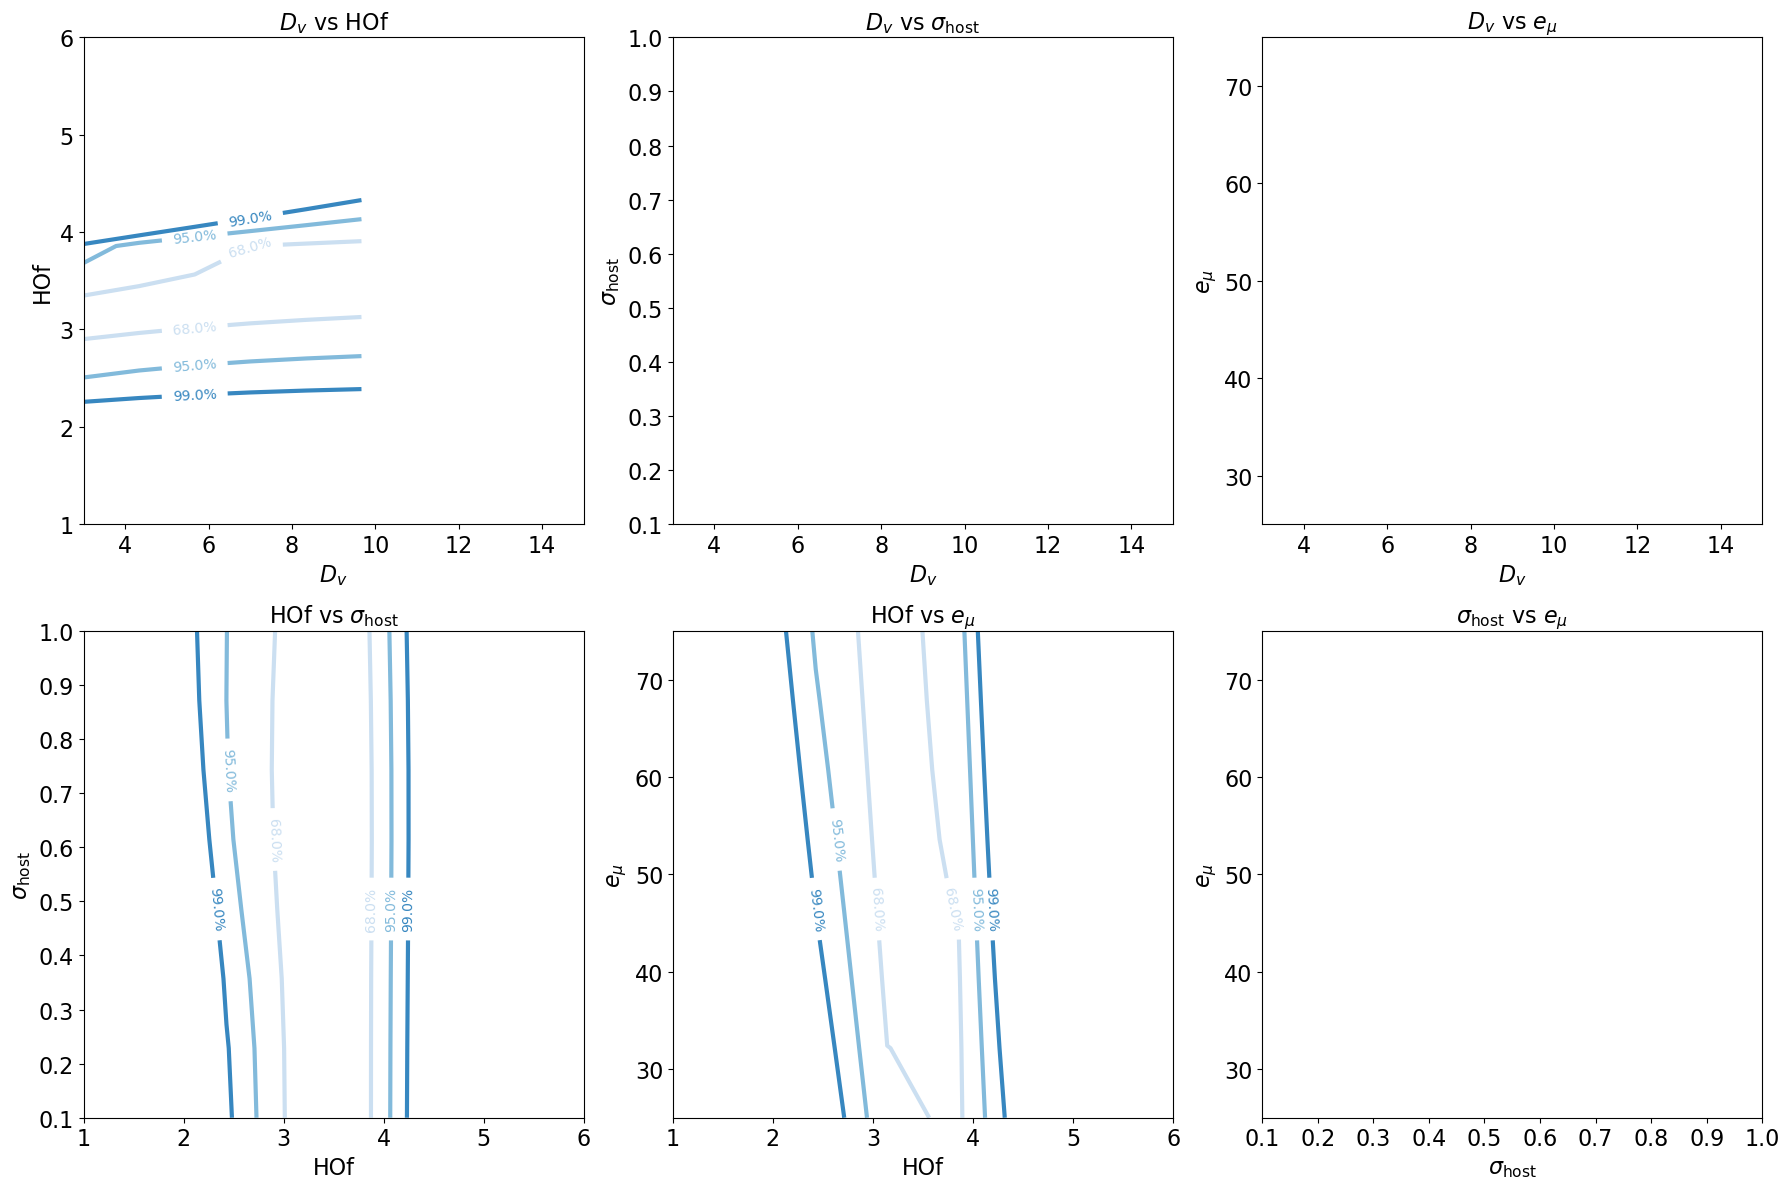

In [34]:
confidence_levels = [0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    (r"$D_v$", "HOf", (2, 3), Dv_h, h_Dv),
    (r"$D_v$", r"$\sigma_{\rm host}$", (1, 3), Dv_sigma, sigma_Dv),
    (r"$D_v$", r"$e_{\mu}$", (1, 2), Dv_e_mu, e_mu_Dv),
    ("HOf", r"$\sigma_{\rm host}$", (0, 3), h_sigma, sigma_h),
    ("HOf", r"$e_{\mu}$", (0, 2), h_e_mu, e_mu_h),
    (r"$\sigma_{\rm host}$", r"$e_{\mu}$", (0, 1), sigma_e_mu, e_mu_sigma)
]

blues = cm.get_cmap("Blues", 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
  
    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_mock, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    # cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g'], linestyles='--')
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=[blues(2), blues(4), blues(6)], extend='max', linewidths=3)
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=10)
    for label in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        # label.set_fontname('Arial')
        label.set_fontsize(16)

plt.tight_layout()
plt.show()

In [24]:
# posterior_4D = posterior_analysis(Dv_4D, Dv_array, HOf_array, sigma_host_array, e_mu_array, data_Macq)



Computing posteriors:   0%|                                                                      | 0/5 [00:00<?, ?it/s]

NameError: name 'sigma_var' is not defined